In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r '/content/drive/MyDrive/UNSW-NB15' '/content/'

In [3]:
import torch, sys
print(f'Python version: {sys.version.split()[0]}')
print(f'Pytorch version: {torch.version}')
print(f'Cuda Version : {torch.version.cuda}')

!pip install torch_geometric -q

# TORCH = torch.__version__.split("+")[0]          # e.g. "2.3.0"
# CUDA  = "cu" + torch.version.cuda.replace(".","")[:4]  # e.g. "cu121"
# !pip install torch_scatter torch_sparse \
#     -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html -q

!pip install pandas numpy scikit-learn matplotlib seaborn networkx tqdm -q

print('All packges are Installed !')

Python version: 3.12.13
Pytorch version: <module 'torch.version' from '/usr/local/lib/python3.12/dist-packages/torch/version.py'>
Cuda Version : None
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00
All packges are Installed !


In [4]:
import os, random, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data   import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn     import MessagePassing

from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.metrics        import (classification_report,
                                    confusion_matrix,
                                    roc_auc_score, f1_score)

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED);  np.random.seed(SEED);  torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [5]:
# ══════════════════════════════════════════════════════════
# MOD-CFG │ Master config (multi-class)
# ══════════════════════════════════════════════════════════
CFG = {
    # ── data ──────────────────────────────────────────────
    "data_dir"       : "/content/UNSW-NB15/", # Changed to ensure consistency
    "min_window"     : 100,
    "max_window"     : 800,
    # ── training ──────────────────────────────────────────
    "n_train"        : 200,
    "n_val"          : 50,
    "n_test"         : 50,
    # ── graph ─────────────────────────────────────────────
    "max_ip_edges"   : 8,
    "temporal_k"     : 5,
    "edge_dim"       : 7,
    # ── model ─────────────────────────────────────────────
    "hidden_dim"     : 128,
    "num_layers"     : 3,
    "dropout"        : 0.3,
    # ── optimiser ─────────────────────────────────────────
    "batch_size"     : 16,
    "lr"             : 1e-3,
    "weight_decay"   : 1e-5,
    "epochs"         : 100,
    "patience"       : 15,
    # ── sampler ───────────────────────────────────────────
    "stratify_train" : True,
    "stratify_eval"  : True, # Changed to True for consistency
    # ── multi-class (NEW) ─────────────────────────────────
    "num_attack_cls" : 9,          # 9 attack categories
    "min_rare_attacks": 1,         # min rare-class nodes per window
}

NODE_DIM = 37
SEED     = 42
print("CFG loaded ✅")
for k, v in CFG.items():
    print(f"  {k:<17} = {str(v):<}")

CFG loaded ✅
  data_dir          = /content/UNSW-NB15/
  min_window        = 100
  max_window        = 800
  n_train           = 200
  n_val             = 50
  n_test            = 50
  max_ip_edges      = 8
  temporal_k        = 5
  edge_dim          = 7
  hidden_dim        = 128
  num_layers        = 3
  dropout           = 0.3
  batch_size        = 16
  lr                = 0.001
  weight_decay      = 1e-05
  epochs            = 100
  patience          = 15
  stratify_train    = True
  stratify_eval     = True
  num_attack_cls    = 9
  min_rare_attacks  = 1


In [6]:
# ── Cell 4: Column definitions & loader ────────────────────────────────────

COLUMNS = [
    "srcip","sport","dstip","dsport","proto","state","dur",
    "sbytes","dbytes","sttl","dttl","sloss","dloss","service",
    "sload","dload","spkts","dpkts","swin","dwin","stcpb","dtcpb",
    "sinpkt","dinpkt","sjit","djit","stime","ltime","tcprtt",
    "synack","ackdat","smean","dmean","trans_depth","response_body_len",
    "ct_srv_src","ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm",
    "ct_dst_sport_ltm","ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd",
    "ct_flw_http_mthd","ct_src_ltm","ct_srv_dst","is_sm_ips_ports",
    "attack_cat","label"
]

# Features used as NODE features (exclude IPs, ports, timestamps, label)
GRAPH_COLS = [
    "dur","sbytes","dbytes","sttl","dttl","sloss","dloss",
    "sload","dload","spkts","dpkts","swin","dwin","sinpkt","dinpkt",
    "sjit","djit","tcprtt","synack","ackdat","smean","dmean",
    "trans_depth","response_body_len","ct_srv_src","ct_state_ttl",
    "ct_dst_ltm","ct_src_dport_ltm","ct_dst_sport_ltm","ct_dst_src_ltm",
    "ct_src_ltm","ct_srv_dst","is_ftp_login","is_sm_ips_ports",
    # encoded categoricals added later:
    "proto_enc","state_enc","service_enc"
]

def load_unswnb15(data_dir: str) -> pd.DataFrame:
    """Load all UNSW-NB15 CSV files from a folder into one DataFrame."""
    data_dir = Path(data_dir)
    csv_files = sorted(data_dir.glob("UNSW-NB15_*.csv"))

    if not csv_files:
        # fallback: grab any .csv in the folder
        csv_files = sorted(data_dir.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")

    print(f"Found {len(csv_files)} file(s):")
    frames = []
    for f in csv_files:
        print(f"  Loading {f.name} ...", end=" ")
        # detect whether header row is present
        first = pd.read_csv(f, nrows=1, header=None).iloc[0, 0]
        has_header = str(first).lower() == "srcip"

        df = pd.read_csv(
            f,
            header=0 if has_header else None,
            names=None if has_header else COLUMNS,
            low_memory=False
        )
        # ensure column names are always lowercase & stripped
        df.columns = [c.strip().lower() for c in df.columns]
        frames.append(df)
        print(f"{len(df):,} rows")

    combined = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows: {len(combined):,}  |  Columns: {combined.shape[1]}")
    return combined

# ── Load ────────────────────────────────────────────────────────────────────
raw_df = load_unswnb15(CFG["data_dir"])
raw_df.head(3)

Found 5 file(s):
  Loading UNSW-NB15_1.csv ... 700,001 rows
  Loading UNSW-NB15_2.csv ... 700,001 rows
  Loading UNSW-NB15_3.csv ... 700,001 rows
  Loading UNSW-NB15_4.csv ... 440,044 rows
  Loading UNSW-NB15_LIST_EVENTS.csv ... 209 rows

Total rows: 2,540,256  |  Columns: 49


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132.0,164.0,31.0,...,0,3.0,7.0,1.0,3.0,1.0,1.0,1.0,NaN,0.0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528.0,304.0,31.0,...,0,2.0,4.0,2.0,3.0,1.0,1.0,2.0,NaN,0.0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146.0,178.0,31.0,...,0,12.0,8.0,1.0,2.0,2.0,1.0,1.0,NaN,0.0


In [7]:
# ── Cell 8: Drop garbage rows & fix labels ──────────────────────────────────

print(f"Rows before cleaning : {len(raw_df):,}")

df = raw_df.copy()

# 1. Drop the 209 embedded-header / corrupt rows
#    (they have NaN in stime which is always set for real flows)
df = df.dropna(subset=["stime"]).copy()
print(f"Rows after drop      : {len(df):,}  (dropped {len(raw_df)-len(df):,} rows)")

# 2. Fix attack_cat — NaN means Normal flow
df["attack_cat"] = (df["attack_cat"]
                    .fillna("Normal")
                    .astype(str).str.strip().str.title())
df.loc[df["label"] == 0, "attack_cat"] = "Normal"

# 3. Ensure label is clean integer
df["label"] = df["label"].astype(int)

# 4. Parse timestamps as float (Unix epoch seconds)
df["stime"] = pd.to_numeric(df["stime"], errors="coerce")
df["ltime"] = pd.to_numeric(df["ltime"], errors="coerce")

print(f"\nLabel distribution after cleaning:")
vc = df["label"].value_counts()
for lbl, cnt in vc.items():
    name = "Normal" if lbl == 0 else "Attack"
    print(f"  {name} ({lbl}): {cnt:,}  ({100*cnt/len(df):.1f}%)")

Rows before cleaning : 2,540,256
Rows after drop      : 2,540,047  (dropped 209 rows)

Label distribution after cleaning:
  Normal (0): 2,218,764  (87.4%)
  Attack (1): 321,283  (12.6%)


In [8]:
# ── Cell 9: Encode categoricals ─────────────────────────────────────────────

CAT_COLS = ["proto", "state", "service"]
encoders = {}

for col in CAT_COLS:
    # clean whitespace / case
    df[col] = df[col].fillna("unknown").astype(str).str.strip().str.lower()
    le = LabelEncoder()
    df[f"{col}_enc"] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col:<10}: {len(le.classes_):>3} unique values  "
          f"→  {col}_enc   "
          f"(e.g. {list(le.classes_[:4])} …)")

# Fix port columns — used only for edge construction (keep as string keys)
for port_col in ["sport", "dsport"]:
    df[port_col] = (pd.to_numeric(df[port_col], errors="coerce")
                    .fillna(0).astype(int).astype(str))

# Fix IP columns — used only for edge construction (keep as strings)
df["srcip"] = df["srcip"].fillna("0.0.0.0").astype(str).str.strip()
df["dstip"] = df["dstip"].fillna("0.0.0.0").astype(str).str.strip()

print("\nCategorical encoding done ✅")

proto     : 135 unique values  →  proto_enc   (e.g. ['3pc', 'a/n', 'aes-sp3-d', 'any'] …)
state     :  16 unique values  →  state_enc   (e.g. ['acc', 'clo', 'con', 'eco'] …)
service   :  13 unique values  →  service_enc   (e.g. ['-', 'dhcp', 'dns', 'ftp'] …)

Categorical encoding done ✅


In [9]:
# ── Cell 10 (FIXED): Impute & normalize ─────────────────────────────────────

# Numerical columns that become NODE FEATURES
# (IPs, raw ports, timestamps, attack_cat, label are excluded)
NUM_FEAT_COLS = [
    "dur","sbytes","dbytes","sttl","dttl","sloss","dloss",
    "sload","dload","spkts","dpkts","swin","dwin","sinpkt","dinpkt",
    "sjit","djit","tcprtt","synack","ackdat","smean","dmean",
    "trans_depth","response_body_len","ct_srv_src","ct_state_ttl",
    "ct_dst_ltm","ct_src_dport_ltm","ct_dst_sport_ltm","ct_dst_src_ltm",
    "ct_src_ltm","ct_srv_dst","is_ftp_login","is_sm_ips_ports",
]

# ── 1. Force ALL numerical columns to float (kills ' ' whitespace strings) ──
print("Converting columns to numeric...")
problematic = []
for col in NUM_FEAT_COLS:
    before_nulls = df[col].isnull().sum()
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors="coerce")
    after_nulls  = df[col].isnull().sum()
    new_nulls    = after_nulls - before_nulls
    if new_nulls > 0:
        problematic.append((col, new_nulls))

if problematic:
    print(f"\n⚠️  Whitespace/bad strings coerced to NaN in {len(problematic)} columns:")
    for col, n in problematic:
        print(f"    {col:<30} → {n:,} new NaNs")
else:
    print("  No hidden string values found.")

# ── 2. Replace inf values ─────────────────────────────────────────────────────
inf_count = np.isinf(df[NUM_FEAT_COLS].values).sum()
df[NUM_FEAT_COLS] = df[NUM_FEAT_COLS].replace([np.inf, -np.inf], np.nan)
print(f"\nReplaced {inf_count} inf values with NaN")

# ── 3. Fill all NaN with 0 ────────────────────────────────────────────────────
nan_count = df[NUM_FEAT_COLS].isnull().sum().sum()
df[NUM_FEAT_COLS] = df[NUM_FEAT_COLS].fillna(0)
print(f"Filled  {nan_count} NaN values with 0")

# ── 4. Final dtype check before scaling ──────────────────────────────────────
bad_cols = [c for c in NUM_FEAT_COLS
            if not pd.api.types.is_numeric_dtype(df[c])]
if bad_cols:
    print(f"\n❌ Still non-numeric: {bad_cols}")
else:
    print("All NUM_FEAT_COLS are numeric ✅")

# ── 5. StandardScaler ─────────────────────────────────────────────────────────
scaler = StandardScaler()
df[NUM_FEAT_COLS] = scaler.fit_transform(df[NUM_FEAT_COLS])
print(f"Normalized {len(NUM_FEAT_COLS)} numerical features (StandardScaler) ✅")

# ── 6. Scale encoded categoricals to [0, 1] ──────────────────────────────────
for col in ["proto_enc", "state_enc", "service_enc"]:
    max_val = df[col].max()
    df[col] = df[col] / max_val if max_val > 0 else df[col]

# ── 7. Final GRAPH_COLS list ──────────────────────────────────────────────────
GRAPH_COLS = NUM_FEAT_COLS + ["proto_enc", "state_enc", "service_enc"]
NODE_DIM   = len(GRAPH_COLS)

print(f"\nNode feature dimension: {NODE_DIM}")

Converting columns to numeric...

⚠️  Whitespace/bad strings coerced to NaN in 1 columns:
    ct_dst_sport_ltm               → 1,429,879 new NaNs

Replaced 0 inf values with NaN
Filled  4207903 NaN values with 0
All NUM_FEAT_COLS are numeric ✅
Normalized 34 numerical features (StandardScaler) ✅

Node feature dimension: 37


In [10]:
# ── Cell 11: Sort, class weights, sanity check ───────────────────────────────

# Sort by start time — CRITICAL for temporal window sampling
df = df.sort_values("stime").reset_index(drop=True)
print("Sorted by stime ✅")

# ── Sanity checks ────────────────────────────────────────────────────────────
assert all(c in df.columns for c in GRAPH_COLS), "❌ Some GRAPH_COLS missing!"
assert df[GRAPH_COLS].isnull().sum().sum() == 0,  "❌ NaN values remain!"
assert not np.isinf(df[GRAPH_COLS].values).any(), "❌ Inf values remain!"
print("Sanity checks passed ✅")

# ── Class weights (for imbalanced loss) ─────────────────────────────────────
n_total  = len(df)
n_normal = (df["label"] == 0).sum()
n_attack = (df["label"] == 1).sum()

w_normal = n_total / (2 * n_normal)
w_attack = n_total / (2 * n_attack)
CLASS_WEIGHTS = torch.tensor([w_normal, w_attack],
                               dtype=torch.float32).to(DEVICE)

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print(f"  Flows        : {n_total:,}")
print(f"  Node feat dim: {NODE_DIM}")
print(f"  Normal flows : {n_normal:,}  ({100*n_normal/n_total:.1f}%)")
print(f"  Attack flows : {n_attack:,}  ({100*n_attack/n_total:.1f}%)")
print(f"  Class weights: Normal={w_normal:.3f}  Attack={w_attack:.3f}")
print(f"  stime range  : {df['stime'].min():.0f} → {df['stime'].max():.0f}")
print("=" * 50)
print("\n✅ Preprocessing complete — ready for Step 4!")

Sorted by stime ✅
Sanity checks passed ✅

  Flows        : 2,540,047
  Node feat dim: 37
  Normal flows : 2,218,764  (87.4%)
  Attack flows : 321,283  (12.6%)
  Class weights: Normal=0.572  Attack=3.953
  stime range  : 0 → 1483831

✅ Preprocessing complete — ready for Step 4!


In [12]:
# ── Cell 12: Stratified split (fixes temporal concentration problem) ─────────
#
#  Why NOT a plain temporal split:
#    Early third → 320,873 attacks | Mid → 268 | Late → 142  (unusable)
#
#  Fix: split attack rows and normal rows separately (70/15/15 each),
#       then re-merge and sort by stime — temporal order is preserved
#       WITHIN each split, just not across splits.

np.random.seed(SEED)

# Separate by class
idx_normal = df[df["label"] == 0].index.to_numpy()
idx_attack = df[df["label"] == 1].index.to_numpy()

# Shuffle each independently before splitting
np.random.shuffle(idx_normal)
np.random.shuffle(idx_attack)

def stratified_split(idx, ratios=(0.70, 0.15, 0.15)):
    n  = len(idx)
    t1 = int(n * ratios[0])
    t2 = int(n * (ratios[0] + ratios[1]))
    return idx[:t1], idx[t1:t2], idx[t2:]

norm_tr, norm_val, norm_te = stratified_split(idx_normal)
att_tr,  att_val,  att_te  = stratified_split(idx_attack)

def build_split(norm_idx, att_idx, label):
    combined = np.concatenate([norm_idx, att_idx])
    split    = df.loc[combined].sort_values("stime").reset_index(drop=True)
    n_att    = (split["label"] == 1).sum()
    print(f"  {label:<6}: {len(split):>9,} flows  |  "
          f"attacks: {n_att:,} ({100*n_att/len(split):.1f}%)  |  "
          f"stime: {split['stime'].min():.0f}–{split['stime'].max():.0f}")
    return split

print("Stratified splits (sorted by stime within each):")
df_train = build_split(norm_tr,  att_tr,  "Train")
df_val   = build_split(norm_val, att_val, "Val  ")
df_test  = build_split(norm_te,  att_te,  "Test ")
print(f"\n✅ Each split has {0.126*100:.1f}% attack rate (mirrors full dataset)")

Stratified splits (sorted by stime within each):
  Train : 1,778,032 flows  |  attacks: 224,898 (12.6%)  |  stime: 0–1483831
  Val   :   381,007 flows  |  attacks: 48,192 (12.6%)  |  stime: 0–1208843
  Test  :   381,008 flows  |  attacks: 48,193 (12.6%)  |  stime: 0–1174994

✅ Each split has 12.6% attack rate (mirrors full dataset)


In [13]:
# ══════════════════════════════════════════════════════════
# MC-1 │ Multi-class label encoder
# ══════════════════════════════════════════════════════════
from sklearn.preprocessing import LabelEncoder


# 1. Normalise category strings across all splits
for _df in [df_train, df_val, df_test]:
    _df["attack_cat"] = _df["attack_cat"].str.strip()
    _df["attack_cat"] = _df["attack_cat"].replace("Backdoors", "Backdoor")

# 2. Fit encoder ONLY on attack flows from train split
#    (val/test must not influence the class mapping)
_attack_cats_train = df_train[df_train["label"] == 1]["attack_cat"]

cat_encoder = LabelEncoder()
cat_encoder.fit(_attack_cats_train)

NUM_ATTACK_CLS = len(cat_encoder.classes_)

# 3. Print class mapping
print(f"NUM_ATTACK_CLS = {NUM_ATTACK_CLS}\n")
print(f"{'Idx':>3}  {'Class Name':<22}  {'Train Flows':>12}")
print("─" * 42)
for idx, name in enumerate(cat_encoder.classes_):
    count = (_attack_cats_train == name).sum()
    print(f"  {idx}  {name:<22}  {count:>12,}")

NUM_ATTACK_CLS = 9

Idx  Class Name               Train Flows
──────────────────────────────────────────
  0  Analysis                       1,917
  1  Backdoor                       1,617
  2  Dos                           11,436
  3  Exploits                      31,207
  4  Fuzzers                       16,925
  5  Generic                      150,894
  6  Reconnaissance                 9,717
  7  Shellcode                      1,064
  8  Worms                            121


In [14]:
# ══════════════════════════════════════════════════════════
# MC-2 │ Assign cat_label to df_train / df_val / df_test
# ══════════════════════════════════════════════════════════

def assign_cat_labels(df, encoder):
    """
    Adds 'cat_label' column:
      -1  → Normal flow  (masked out of multi-class loss)
      0-8 → Attack class (what the model learns to predict)

    Normal flows stay in the DataFrame so the graph edge
    structure stays realistic — they're just ignored in loss.
    """
    df = df.copy()
    df["cat_label"] = -1                          # default: Normal → masked

    attack_mask = df["label"] == 1
    df.loc[attack_mask, "cat_label"] = encoder.transform(
        df.loc[attack_mask, "attack_cat"].values
    )
    return df

df_train = assign_cat_labels(df_train, cat_encoder)
df_val   = assign_cat_labels(df_val,   cat_encoder)
df_test  = assign_cat_labels(df_test,  cat_encoder)

# ── Sanity checks ─────────────────────────────────────────
print(f"{'Split':<8} {'Normal (−1)':>12} {'Attack (0-8)':>13} {'Classes present'}")
print("─" * 60)
for split_name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    n_normal  = (df["cat_label"] == -1).sum()
    n_attack  = (df["cat_label"] >=  0).sum()
    classes   = sorted(df[df["cat_label"] >= 0]["cat_label"].unique().tolist())
    print(f"{split_name:<8} {n_normal:>12,} {n_attack:>13,} {classes}")

# Hard assertions — will raise if something is wrong
assert df_train["cat_label"].isna().sum() == 0, "NaN in cat_label!"
assert df_val["cat_label"].isna().sum()   == 0, "NaN in cat_label!"
assert df_test["cat_label"].isna().sum()  == 0, "NaN in cat_label!"
assert set(df_train[df_train["label"] == 1]["cat_label"].unique()) == set(range(NUM_ATTACK_CLS)), \
    "Train split is missing some attack classes!"

print("\n✅ cat_label assigned correctly on all splits")

Split     Normal (−1)  Attack (0-8) Classes present
────────────────────────────────────────────────────────────
train       1,553,134       224,898 [0, 1, 2, 3, 4, 5, 6, 7, 8]
val           332,815        48,192 [0, 1, 2, 3, 4, 5, 6, 7, 8]
test          332,815        48,193 [0, 1, 2, 3, 4, 5, 6, 7, 8]

✅ cat_label assigned correctly on all splits


In [15]:
# ══════════════════════════════════════════════════════════
# MC-3 │ Attack class weights (inverse frequency)
# ══════════════════════════════════════════════════════════
from collections import Counter

# Count from TRAIN attack flows only
_attack_counts = Counter(
    df_train[df_train["label"] == 1]["cat_label"].values
)
_total = sum(_attack_counts.values())

attack_weights = torch.zeros(NUM_ATTACK_CLS, dtype=torch.float32)
for cls_idx, count in _attack_counts.items():
    attack_weights[cls_idx] = _total / (NUM_ATTACK_CLS * count)

attack_weights = attack_weights.to(DEVICE)

# ── Print weight table ────────────────────────────────────
print(f"{'Idx':>3}  {'Class':<22}  {'Count':>8}  {'Weight':>8}  {'Note'}")
print("─" * 62)
for idx, name in enumerate(cat_encoder.classes_):
    count = _attack_counts.get(idx, 0)
    w     = attack_weights[idx].item()
    note  = "⚠️  rare — high weight" if count < 2_000 else ""
    print(f"  {idx}  {name:<22}  {count:>8,}  {w:>8.3f}  {note}")

print(f"\nWeight range: {attack_weights.min():.3f} → {attack_weights.max():.3f}")
print(f"(Generic is the anchor class at ≈ 1.0, Worms will be highest)")

Idx  Class                      Count    Weight  Note
──────────────────────────────────────────────────────────────
  0  Analysis                   1,917    13.035  ⚠️  rare — high weight
  1  Backdoor                   1,617    15.454  ⚠️  rare — high weight
  2  Dos                       11,436     2.185  
  3  Exploits                  31,207     0.801  
  4  Fuzzers                   16,925     1.476  
  5  Generic                  150,894     0.166  
  6  Reconnaissance             9,717     2.572  
  7  Shellcode                  1,064    23.486  ⚠️  rare — high weight
  8  Worms                        121   206.518  ⚠️  rare — high weight

Weight range: 0.166 → 206.518
(Generic is the anchor class at ≈ 1.0, Worms will be highest)


In [16]:
# ── Cell 13: RandomWindowSampler ─────────────────────────────────────────────

class RandomWindowSampler:
    """
    Samples random contiguous windows from a time-sorted DataFrame.

    Two modes:
      plain       — pure random (start, size)
      stratified  — guarantees at least min_attacks attack flows per window
                    by rejecting windows that are too attack-sparse
                    (with a max_retries cap to avoid infinite loops)
    """

    def __init__(self, dataframe: pd.DataFrame,
                 min_size: int,
                 max_size: int,
                 min_attacks: int = 1,
                 max_retries: int = 20,
                 seed: int = 42):

        assert len(dataframe) > max_size, \
            f"DataFrame ({len(dataframe)}) must be > max_size ({max_size})"

        self.df          = dataframe.reset_index(drop=True)
        self.min_size    = min_size
        self.max_size    = max_size
        self.min_attacks = min_attacks   # minimum attack flows per window
        self.max_retries = max_retries
        self.rng         = np.random.default_rng(seed)

        # pre-compute cumulative attack count for fast range queries
        self._cum_attacks = self.df["label"].cumsum().to_numpy()
        self._n_calls     = 0
        self._n_retries   = 0

    # ── internal ────────────────────────────────────────────────────────────
    def _draw(self):
        """Draw one (start, size) pair."""
        size  = int(self.rng.integers(self.min_size, self.max_size + 1))
        start = int(self.rng.integers(0, len(self.df) - size + 1))
        return start, size

    def _attacks_in(self, start, size):
        """Count attacks in [start, start+size) using prefix sum — O(1)."""
        end = start + size - 1
        a   = self._cum_attacks[end]
        b   = self._cum_attacks[start - 1] if start > 0 else 0
        return int(a - b)

    # ── public ──────────────────────────────────────────────────────────────
    def sample(self, stratified: bool = True) -> pd.DataFrame:
        """
        Return one random window.
        If stratified=True, retry until window has >= min_attacks attacks.
        """
        self._n_calls += 1

        for attempt in range(self.max_retries):
            start, size = self._draw()
            if not stratified or \
               self._attacks_in(start, size) >= self.min_attacks:
                return self.df.iloc[start : start + size].reset_index(drop=True)
            self._n_retries += 1

        # fallback — return last draw even if attack-sparse
        return self.df.iloc[start : start + size].reset_index(drop=True)

    def sample_n(self, n: int, stratified: bool = True) -> list:
        return [self.sample(stratified) for _ in range(n)]

    # ── diagnostics ─────────────────────────────────────────────────────────
    def stats(self, n: int = 300, stratified: bool = True) -> dict:
        sizes, rates = [], []
        for _ in range(n):
            w = self.sample(stratified)
            sizes.append(len(w))
            rates.append((w["label"] == 1).mean())
        retry_rate = self._n_retries / max(self._n_calls, 1)
        return dict(size_mean=np.mean(sizes), size_std=np.std(sizes),
                    size_min=np.min(sizes),   size_max=np.max(sizes),
                    attack_mean=np.mean(rates), attack_std=np.std(rates),
                    retry_rate=retry_rate)

    def __repr__(self):
        return (f"RandomWindowSampler(n={len(self.df):,}, "
                f"win=[{self.min_size},{self.max_size}], "
                f"min_attacks={self.min_attacks}, "
                f"calls={self._n_calls}, retries={self._n_retries})")

In [19]:
# ── Cell 14c: Fix val/test samplers (min_attacks=1) ─────────────────────────
#
#  Problem: stratified=False gave 44.4% zero-attack windows in val/test
#           → half of evaluation graphs have nothing to detect
#
#  Fix: use min_attacks=1 for val/test
#       - guarantees at least 1 attack per window
#       - much lower bias than train's min_attacks=3
#       - realistic attack rate still maintained (~13%)

train_sampler = RandomWindowSampler(df_train,
                                    CFG["min_window"], CFG["max_window"],
                                    min_attacks=3, seed=42)
val_sampler  = RandomWindowSampler(df_val,
                                   CFG["min_window"], CFG["max_window"],
                                   min_attacks=1, seed=43)
test_sampler = RandomWindowSampler(df_test,
                                   CFG["min_window"], CFG["max_window"],
                                   min_attacks=1, seed=44)

# ── Quick re-check on 200 windows ────────────────────────────────────────────
print("Re-checking val/test with min_attacks=1 …\n")
for name, sampler, strat in [
    ("Train", train_sampler, True ),   # unchanged
    ("Val  ", val_sampler,   True ),   # now min_attacks=1
    ("Test ", test_sampler,  True ),   # now min_attacks=1
]:
    windows      = sampler.sample_n(200, stratified=strat)
    sizes        = [len(w)                       for w in windows]
    rates        = [(w["label"]==1).mean()        for w in windows]
    zero_attack  = sum(1 for w in windows if (w["label"]==1).sum() == 0)
    retry_rate   = sampler._n_retries / max(sampler._n_calls, 1)

    print(f"  {name}  |  "
          f"attack rate: {np.mean(rates):.1%} ± {np.std(rates):.1%}  |  "
          f"zero-attack windows: {zero_attack}/200  |  "
          f"retry rate: {100*retry_rate:.0f}%")

# ── Update CFG ────────────────────────────────────────────────────────────────
CFG["stratify_train"] = True
CFG["stratify_eval"]  = True   # now True for both (min_attacks=1 is the control)

# ── Rare category note ────────────────────────────────────────────────────────
print("""
── Rare category note ──────────────────────────────────────────
  Worms      :  12/100 train windows  ← very rare, dataset limitation
  Backdoors  :  21/100 train windows  ← sparse but acceptable

  These categories will have higher misclassification rates.
  The weighted cross-entropy loss partially compensates.
  Report per-category metrics in Step 9 to track this explicitly.
────────────────────────────────────────────────────────────────
""")

print("✅ Samplers updated — ready for Step 5: Graph Construction!")

Re-checking val/test with min_attacks=1 …

  Train  |  attack rate: 27.2% ± 16.9%  |  zero-attack windows: 0/200  |  retry rate: 150%
  Val    |  attack rate: 23.3% ± 22.3%  |  zero-attack windows: 0/200  |  retry rate: 96%
  Test   |  attack rate: 22.6% ± 18.8%  |  zero-attack windows: 0/200  |  retry rate: 74%

── Rare category note ──────────────────────────────────────────
  Worms      :  12/100 train windows  ← very rare, dataset limitation
  Backdoors  :  21/100 train windows  ← sparse but acceptable

  These categories will have higher misclassification rates.
  The weighted cross-entropy loss partially compensates.
  Report per-category metrics in Step 9 to track this explicitly.
────────────────────────────────────────────────────────────────

✅ Samplers updated — ready for Step 5: Graph Construction!


In [31]:
# ── Cell 14 addition — after building samplers ───────────────────────────────
# Training: stratified=True  → biased toward attacks (helps learning)
# Val/Test: stratified=True  → ensures at least `min_attacks` per window (avoids empty graphs for evaluation)

# Test it:
ex_train = train_sampler.sample(stratified=True)
ex_val   = val_sampler.sample(stratified=True)    # Changed to stratified=True for consistency

print(f"Train window attack rate : {(ex_train['label']==1).mean():.1%}  (stratified, target ~27% avg)")
print(f"Val   window attack rate : {(ex_val['label']==1).mean():.1%}  (stratified, target ~23% avg)")
print("\n✅ Step 4 fully complete — samplers ready!")

Train window attack rate : 6.5%  (stratified, target ~27% avg)
Val   window attack rate : 6.3%  (stratified, target ~23% avg)

✅ Step 4 fully complete — samplers ready!


# Now on to Step 5: Graph Construction — the most important step. Here's what we're building before writing any code:

### Each flow → Node
* **flow_i**
* **37 features**
* `(dur, sbytes, dbytes, sttl, sload, dload, spkts, dpkts, proto_enc, state_enc ...)`
* `label: 0=Normal 1=Attack`

### 3 Edge Types
* **Same source IP**: flows from the same host
* **Same destination IP**: flows targeting same server
* **Temporal proximity**: *k* nearest flows in time
* **Max edges per group: 8**

### Edge Attributes (7-dim)
1. `src_ip_match` [0/1]
2. `dst_ip_match` [0/1]
3. `temporal_edge` [0/1]
4. `time_diff` [0..1]
5. `proto_match` [0/1]
6. `service_match` [0/1]
7. `port_overlap` [0/1]
* `edge_dim = 7` (fixed in CFG)

### Window DataFrame → PyG Data(x, edge_index, edge_attr, y)
`x: [N, 37]  edge_index: [2, E]  edge_attr: [E, 7]  y: [N] (N=flows, E=edges)`

### Design decisions (why these choices)
* **No same src+dst pair edge** — already captured by combining src+dst edges individually
* **Max 8 edges per IP group** — prevents O(N²) explosion in large windows (800 flows × same IP)
* **k=5 temporal neighbours** — captures local burst patterns without over-connecting
* **Undirected graph** — both directions added; GraphSAGE aggregates symmetrically
* **Self-loops excluded** — SAGEConv adds them internally during aggregation

In [21]:
# ── Cell 15: GraphBuilder ────────────────────────────────────────────────────

class GraphBuilder:
    """
    Converts a window DataFrame into a PyTorch Geometric Data object.

    Nodes  : one per flow, features = GRAPH_COLS (37-dim)
    Edges  : shared srcip | shared dstip | temporal k-NN
    Edge attr: 7-dim vector per edge (see build_edge_attr)
    Label  : per-node binary label (0=Normal, 1=Attack)
    """

    def __init__(self,
                 node_cols   : list,
                 max_ip_edges: int = 8,
                 temporal_k  : int = 5):

        self.node_cols    = node_cols
        self.max_ip_edges = max_ip_edges
        self.temporal_k   = temporal_k

    # ── public ──────────────────────────────────────────────────────────────
    def build(self, window: pd.DataFrame) -> Data:
        """Full pipeline: DataFrame → PyG Data."""
        n = len(window)
        assert n >= 2, "Window must have at least 2 flows"

        # ── node features ────────────────────────────────────────────────────
        x = torch.tensor(
            window[self.node_cols].values, dtype=torch.float32
        )                                                    # [N, 37]

        # ── labels ───────────────────────────────────────────────────────────
        y = torch.tensor(
            window["label"].values, dtype=torch.long
        )                                                    # [N]

        # ── edges ────────────────────────────────────────────────────────────
        src_edges  = self._ip_edges(window, "srcip")
        dst_edges  = self._ip_edges(window, "dstip")
        temp_edges = self._temporal_edges(window)

        # combine all edge types
        all_src  = src_edges[0]  + dst_edges[0]  + temp_edges[0]
        all_dst  = src_edges[1]  + dst_edges[1]  + temp_edges[1]
        all_type = src_edges[2]  + dst_edges[2]  + temp_edges[2]

        if len(all_src) == 0:
            # degenerate window: no edges → fully connect (rare)
            all_src  = list(range(n))
            all_dst  = list(range(n))
            all_type = [2] * n   # mark as temporal

        src_t = torch.tensor(all_src,  dtype=torch.long)
        dst_t = torch.tensor(all_dst,  dtype=torch.long)

        # make undirected (both directions)
        edge_index = torch.stack([
            torch.cat([src_t, dst_t]),
            torch.cat([dst_t, src_t])
        ], dim=0)                                            # [2, 2E]

        # ── edge attributes ──────────────────────────────────────────────────
        edge_attr = self._build_edge_attr(
            window, all_src, all_dst, all_type
        )                                                    # [E, 7]
        # mirror for undirected (attr is symmetric)
        edge_attr = torch.cat([edge_attr, edge_attr], dim=0)  # [2E, 7]

        return Data(x=x, edge_index=edge_index,
                    edge_attr=edge_attr, y=y,
                    num_nodes=n)

    # ── edge builders ────────────────────────────────────────────────────────
    def _ip_edges(self, window: pd.DataFrame,
                  col: str) -> tuple[list, list, list]:
        """
        For each group of flows sharing the same IP (srcip or dstip),
        connect every pair — capped at max_ip_edges per group to avoid
        O(N²) explosion when one IP dominates the window.
        """
        src_list, dst_list, type_list = [], [], []
        edge_type = 0 if col == "srcip" else 1

        for _, group in window.groupby(col):
            idxs = group.index.tolist()   # row positions in window
            if len(idxs) < 2:
                continue

            # sort by time position, take at most max_ip_edges nodes
            idxs = idxs[: self.max_ip_edges + 1]

            for i in range(len(idxs)):
                for j in range(i + 1, len(idxs)):
                    src_list.append(idxs[i])
                    dst_list.append(idxs[j])
                    type_list.append(edge_type)

        return src_list, dst_list, type_list

    def _temporal_edges(self, window: pd.DataFrame
                        ) -> tuple[list, list, list]:
        """
        Connect each flow to its k nearest temporal neighbours.
        Since the window is already sorted by stime, we just connect
        each node to the k nodes before and after it in row order.
        """
        n   = len(window)
        k   = min(self.temporal_k, n - 1)
        src_list, dst_list, type_list = [], [], []

        for i in range(n):
            # look k steps forward only (backward covered by undirected flip)
            for j in range(i + 1, min(i + k + 1, n)):
                src_list.append(i)
                dst_list.append(j)
                type_list.append(2)   # type 2 = temporal

        return src_list, dst_list, type_list

    # ── edge attribute builder ───────────────────────────────────────────────
    def _build_edge_attr(self, window: pd.DataFrame,
                         src_list : list,
                         dst_list : list,
                         type_list: list) -> torch.Tensor:
        """
        Build a 7-dim edge feature vector for each edge:
          [0] src_ip_match   — 1 if same srcip
          [1] dst_ip_match   — 1 if same dstip
          [2] temporal_edge  — 1 if temporal k-NN edge
          [3] time_diff      — normalised |stime_i - stime_j|
          [4] proto_match    — 1 if same protocol
          [5] service_match  — 1 if same service
          [6] port_overlap   — 1 if dport_i == sport_j or vice-versa
        """
        E = len(src_list)
        if E == 0:
            return torch.zeros((0, 7), dtype=torch.float32)

        attrs = np.zeros((E, 7), dtype=np.float32)

        stime   = window["stime"].values
        proto   = window["proto"].values
        service = window["service"].values
        srcip   = window["srcip"].values
        dstip   = window["dstip"].values
        sport   = window["sport"].values
        dsport  = window["dsport"].values

        # normalisation constant for time differences
        t_range = max(stime.max() - stime.min(), 1.0)

        for k, (i, j, etype) in enumerate(zip(src_list, dst_list, type_list)):
            attrs[k, 0] = float(srcip[i]   == srcip[j])     # src IP match
            attrs[k, 1] = float(dstip[i]   == dstip[j])     # dst IP match
            attrs[k, 2] = float(etype == 2)                  # temporal edge
            attrs[k, 3] = abs(stime[i] - stime[j]) / t_range  # time diff
            attrs[k, 4] = float(proto[i]   == proto[j])     # proto match
            attrs[k, 5] = float(service[i] == service[j])   # service match
            attrs[k, 6] = float(                             # port overlap
                sport[i] == dsport[j] or dsport[i] == sport[j]
            )

        return torch.tensor(attrs, dtype=torch.float32)

In [32]:
# ══════════════════════════════════════════════════════════
# MC-4 │ GraphBuilderAttackOnly — subclass of GraphBuilder
# ══════════════════════════════════════════════════════════

class GraphBuilderAttackOnly(GraphBuilder):
    """
    Identical to GraphBuilder in every way except g.y.

    GraphBuilder sets:   g.y = binary label  (0 or 1)
    This class sets:     g.y = cat_label      (-1 or 0-8)

    -1  → Normal node:  included in the graph for realistic
                        edge structure, but masked out of loss
    0-8 → Attack node:  the 9-class target the model learns
    """

    def build(self, window: pd.DataFrame):
        g = super().build(window)           # builds x, edge_index, edge_attr, y
        g.y = torch.tensor(
            window["cat_label"].values,
            dtype=torch.long
        )
        return g


# ── Smoke test ────────────────────────────────────────────
_mc_builder = GraphBuilderAttackOnly(
    node_cols    = GRAPH_COLS,
    max_ip_edges = CFG["max_ip_edges"],
    temporal_k   = CFG["temporal_k"],
)

_window = train_sampler.sample(stratified=True)
_g      = _mc_builder.build(_window)

print("── Shape check ───────────────────────────────")
print(f"  x          : {tuple(_g.x.shape)}   (nodes × node_features)")
print(f"  edge_index : {tuple(_g.edge_index.shape)}")
print(f"  edge_attr  : {tuple(_g.edge_attr.shape)}")
print(f"  y          : {tuple(_g.y.shape)}")
print(f"  y unique   : {sorted(_g.y.unique().tolist())}")

_n_masked = (_g.y == -1).sum().item()
_n_active = (_g.y >=  0).sum().item()
print(f"\n  Normal nodes (masked from loss) : {_n_masked}")
print(f"  Attack nodes (active in loss)   : {_n_active}")
print(f"  Attack classes present          : {sorted(_g.y[_g.y >= 0].unique().tolist())}")

# Hard assertions
assert _g.y.dtype     == torch.long,        "y must be long"
assert -1 in _g.y,                          "No Normal nodes? Check cat_label"
assert _g.y.max().item() <= NUM_ATTACK_CLS - 1, "y out of range"
assert _g.x.shape[1]  == NODE_DIM,          f"Expected {NODE_DIM} node features"
assert _g.edge_attr.shape[1] == CFG["edge_dim"], "Edge dim mismatch"

print("\n✅ GraphBuilderAttackOnly verified")

── Shape check ───────────────────────────────
  x          : (555, 37)   (nodes × node_features)
  edge_index : (2, 8320)
  edge_attr  : (8320, 7)
  y          : (555,)
  y unique   : [-1, 0, 1, 2, 3, 4, 5, 6, 7]

  Normal nodes (masked from loss) : 309
  Attack nodes (active in loss)   : 246
  Attack classes present          : [0, 1, 2, 3, 4, 5, 6, 7]

✅ GraphBuilderAttackOnly verified


In [33]:
# ── Cell 16: Smoke test ──────────────────────────────────────────────────────

builder = GraphBuilder(
    node_cols    = GRAPH_COLS,
    max_ip_edges = CFG["max_ip_edges"],
    temporal_k   = CFG["temporal_k"],
)

# sample one training window and build its graph
sample_window = train_sampler.sample(stratified=True)
g = builder.build(sample_window)

print("── Single graph sanity check ──────────────────────────")
print(f"  Window size (flows)  : {len(sample_window)}")
print(f"  Nodes  x.shape       : {g.x.shape}")
print(f"  Edges  edge_index    : {g.edge_index.shape}  ({g.edge_index.shape[1]} directed edges)")
print(f"  Edge attr            : {g.edge_attr.shape}")
print(f"  Labels y             : {g.y.shape}  unique={g.y.unique().tolist()}")
print(f"  Attacks in window    : {(g.y==1).sum().item()} / {g.num_nodes}")
print(f"  Avg edges per node   : {g.edge_index.shape[1]/g.num_nodes:.1f}")
print()

# check edge attribute ranges
ea = g.edge_attr
print("── Edge attribute stats ───────────────────────────────")
names = ["src_ip_match","dst_ip_match","temporal","time_diff",
         "proto_match","service_match","port_overlap"]
for i, name in enumerate(names):
    col = ea[:, i]
    print(f"  [{i}] {name:<16}  "
          f"min={col.min():.2f}  max={col.max():.2f}  "
          f"mean={col.mean():.2f}")

assert g.x.shape[1]         == NODE_DIM,       "❌ Wrong node feature dim"
assert g.edge_attr.shape[1] == CFG["edge_dim"],"❌ Wrong edge attr dim"
assert not torch.isnan(g.x).any(),             "❌ NaN in node features"
assert not torch.isnan(g.edge_attr).any(),     "❌ NaN in edge attrs"
print("\n✅ All assertions passed!")

── Single graph sanity check ──────────────────────────
  Window size (flows)  : 286
  Nodes  x.shape       : torch.Size([286, 37])
  Edges  edge_index    : torch.Size([2, 5160])  (5160 directed edges)
  Edge attr            : torch.Size([5160, 7])
  Labels y             : torch.Size([286])  unique=[0, 1]
  Attacks in window    : 83 / 286
  Avg edges per node   : 18.0

── Edge attribute stats ───────────────────────────────
  [0] src_ip_match      min=0.00  max=1.00  mean=0.29
  [1] dst_ip_match      min=0.00  max=1.00  mean=0.32
  [2] temporal          min=0.00  max=1.00  mean=0.55
  [3] time_diff         min=0.00  max=0.86  mean=0.10
  [4] proto_match       min=0.00  max=1.00  mean=0.99
  [5] service_match     min=0.00  max=1.00  mean=0.42
  [6] port_overlap      min=0.00  max=0.00  mean=0.00

✅ All assertions passed!


Building 50 graphs …


  0%|          | 0/50 [00:00<?, ?it/s]


── Graph statistics over 50 builds ────────────────
  Nodes  : 454 ± 203  [101–789]
  Edges  : 6656 ± 2397  [1778–10734]
  Edge/node ratio : 14.7
  Attack rate     : 29.3% ± 16.5%


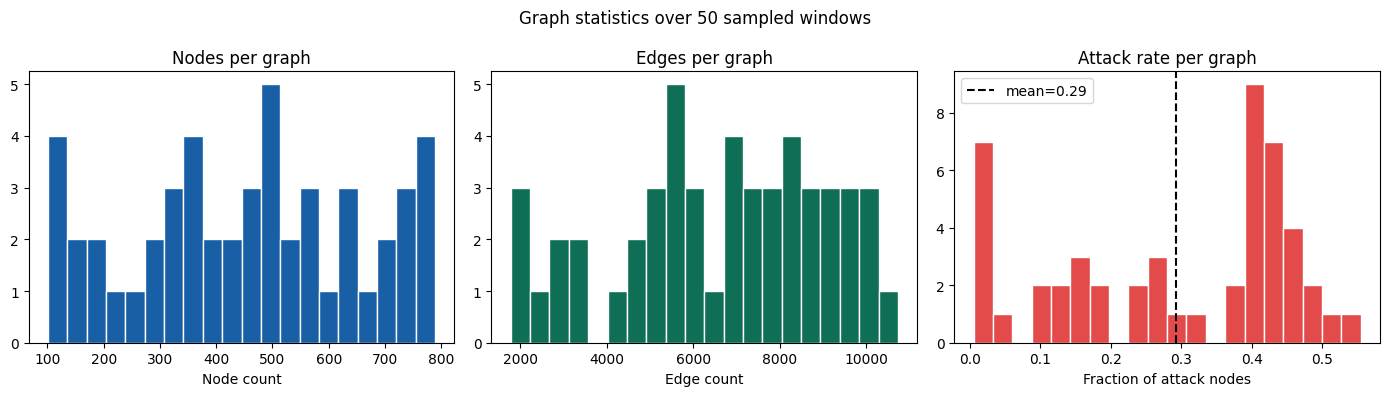


✅ Step 5 complete — GraphBuilder ready!


In [34]:
# ── Cell 17: Benchmark & graph statistics ────────────────────────────────────

N_BENCH = 50
print(f"Building {N_BENCH} graphs …")

node_counts, edge_counts, attack_rates = [], [], []

for _ in tqdm(range(N_BENCH)):
    w = train_sampler.sample(stratified=True)
    g = builder.build(w)
    node_counts.append(g.num_nodes)
    edge_counts.append(g.edge_index.shape[1])
    attack_rates.append((g.y == 1).float().mean().item())

print(f"\n── Graph statistics over {N_BENCH} builds ────────────────")
print(f"  Nodes  : {np.mean(node_counts):.0f} ± {np.std(node_counts):.0f}"
      f"  [{np.min(node_counts)}–{np.max(node_counts)}]")
print(f"  Edges  : {np.mean(edge_counts):.0f} ± {np.std(edge_counts):.0f}"
      f"  [{np.min(edge_counts)}–{np.max(edge_counts)}]")
print(f"  Edge/node ratio : {np.mean(edge_counts)/np.mean(node_counts):.1f}")
print(f"  Attack rate     : {np.mean(attack_rates):.1%} ± {np.std(attack_rates):.1%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Graph statistics over {N_BENCH} sampled windows", fontsize=12)

axes[0].hist(node_counts, bins=20, color="#185FA5", edgecolor="white")
axes[0].set_title("Nodes per graph"); axes[0].set_xlabel("Node count")

axes[1].hist(edge_counts, bins=20, color="#0F6E56", edgecolor="white")
axes[1].set_title("Edges per graph"); axes[1].set_xlabel("Edge count")

axes[2].hist(attack_rates, bins=20, color="#E24B4A", edgecolor="white")
axes[2].set_title("Attack rate per graph")
axes[2].set_xlabel("Fraction of attack nodes")
axes[2].axvline(np.mean(attack_rates), color="black",
                linestyle="--", label=f"mean={np.mean(attack_rates):.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig("/content/graph_stats.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✅ Step 5 complete — GraphBuilder ready!")

# Now the model. Here's what we're building:
graphsage_architecture (2).svg

In [35]:
# ── Cell 18: Custom conv layer ────────────────────────────────────────────────

class EdgeAttrSAGEConv(MessagePassing):
    """
    GraphSAGE convolution that incorporates edge attributes.

    Standard SAGEConv ignores edge features entirely.
    Here we project edge features into the same space as node features
    and ADD them to the neighbour embedding before aggregation.

    Message:   m_ij  = x_j + W_e(e_ij)          ← edge-enhanced neighbour
    Aggregate: agg_i = MEAN({ m_ij : j∈N(i) })
    Update:    h_i   = ReLU( W · [x_i ‖ agg_i] + bias )
    """

    def __init__(self,
                 in_channels : int,
                 out_channels: int,
                 edge_dim    : int,
                 normalize   : bool = True):
        super().__init__(aggr="mean")   # MEAN aggregator
        self.normalize = normalize

        # project edge features → same dim as node features
        self.edge_proj = nn.Sequential(
            nn.Linear(edge_dim, in_channels),
            nn.ReLU(),
        )

        # combine self + aggregated neighbourhood
        self.lin_update = nn.Linear(2 * in_channels, out_channels, bias=False)

        # skip connection: maps input directly to output space
        self.lin_skip   = nn.Linear(in_channels, out_channels, bias=False)

        self.bias = nn.Parameter(torch.zeros(out_channels))

        self._reset_parameters()

    def _reset_parameters(self):
        nn.init.xavier_uniform_(self.lin_update.weight)
        nn.init.xavier_uniform_(self.lin_skip.weight)
        for m in self.edge_proj:
            if hasattr(m, "weight"):
                nn.init.xavier_uniform_(m.weight)

    def forward(self,
                x          : torch.Tensor,        # [N, in_channels]
                edge_index : torch.Tensor,        # [2, E]
                edge_attr  : torch.Tensor         # [E, edge_dim]
                ) -> torch.Tensor:                # [N, out_channels]

        # project edge features to node feature space
        e_emb = self.edge_proj(edge_attr)         # [E, in_channels]

        # propagate: calls message() then aggregate()
        agg = self.propagate(edge_index, x=x, e_emb=e_emb)  # [N, in_channels]

        # update: concat self + neighbourhood, add skip + bias
        out = self.lin_update(torch.cat([x, agg], dim=-1))   # [N, out_channels]
        out = out + self.lin_skip(x) + self.bias

        if self.normalize:
            out = F.normalize(out, p=2, dim=-1)

        return out

    def message(self,
                x_j   : torch.Tensor,    # neighbour features  [E, in_channels]
                e_emb : torch.Tensor     # edge embeddings     [E, in_channels]
                ) -> torch.Tensor:
        # add edge information to the neighbour's feature vector
        return x_j + e_emb              # [E, in_channels]

    def __repr__(self):
        return (f"EdgeAttrSAGEConv("
                f"in={self.lin_skip.in_features}, "
                f"out={self.lin_skip.out_features})")

In [36]:
# ── Cell 19: Full model ───────────────────────────────────────────────────────

class GraphSAGEClassifier(nn.Module):
    """
    Node-level binary classifier using stacked EdgeAttrSAGEConv layers.

    Architecture:
        [Input projection]
            Linear(node_dim → hidden_dim)  + ReLU
        [GraphSAGE layers]  ×  num_layers
            EdgeAttrSAGEConv → BatchNorm → ReLU → Dropout
        [Classifier head]
            Linear(hidden → hidden//2) → ReLU → Linear(hidden//2 → 2)
    """

    def __init__(self,
                 node_dim  : int,
                 edge_dim  : int,
                 hidden_dim: int,
                 num_layers: int,
                 dropout   : float,
                 num_classes: int): # Removed default value = 2
        super().__init__()

        self.num_layers = num_layers
        self.dropout    = dropout

        # ── input projection ─────────────────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.ReLU(),
        )

        # ── GraphSAGE conv layers ─────────────────────────────────────────────
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(
                EdgeAttrSAGEConv(hidden_dim, hidden_dim, edge_dim)
            )
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # ── classifier head ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self,
                x         : torch.Tensor,   # [N, node_dim]
                edge_index: torch.Tensor,   # [2, E]
                edge_attr : torch.Tensor    # [E, edge_dim]
                ) -> torch.Tensor:          # [N, num_classes]

        # project raw features to hidden space
        h = self.input_proj(x)              # [N, hidden_dim]

        # stacked conv → BN → ReLU → dropout
        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, edge_index, edge_attr)   # [N, hidden_dim]
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        # per-node logits
        return self.classifier(h)           # [N, 2]

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [37]:
# ══════════════════════════════════════════════════════════
# MOD-MODEL │ Instantiate multi-class model
# ══════════════════════════════════════════════════════════
model = GraphSAGEClassifier(
    node_dim   = NODE_DIM,
    edge_dim   = CFG["edge_dim"],
    hidden_dim = CFG["hidden_dim"],
    num_layers = CFG["num_layers"],
    dropout    = CFG["dropout"],
    num_classes= CFG["num_attack_cls"],   # 9 ← only change vs binary
).to(DEVICE)

print(f"Parameters : {model.count_parameters():,}")
print(f"Output dim : {CFG['num_attack_cls']} classes")
print(f"Device     : {DEVICE}\n")

# ── Forward pass sanity check ─────────────────────────────
_mc_builder_check = GraphBuilderAttackOnly(
    node_cols=GRAPH_COLS,
    max_ip_edges=CFG["max_ip_edges"],
    temporal_k=CFG["temporal_k"]
)
_g_check = _mc_builder_check.build(train_sampler.sample(stratified=True))
_g_check = _g_check.to(DEVICE)

model.eval()
with torch.no_grad():
    _out = model(_g_check.x, _g_check.edge_index, _g_check.edge_attr)

print(f"Output shape : {tuple(_out.shape)}  → expect [N, 9]")
assert _out.shape[1] == CFG["num_attack_cls"], "Wrong output dim!"
assert not torch.isnan(_out).any(),            "NaN in output!"
print("✅ Model verified")

Parameters : 165,385
Output dim : 9 classes
Device     : cpu

Output shape : (784, 9)  → expect [N, 9]
✅ Model verified


# Training

In [38]:
# ══════════════════════════════════════════════════════════
# MOD-LOSS │ Masked loss + train_epoch + evaluate
# ══════════════════════════════════════════════════════════
import torch.nn.functional as F
from torch_geometric.data import DataLoader as PyGDataLoader
from sklearn.metrics import f1_score, roc_auc_score

# ── Masked cross-entropy ──────────────────────────────────
def masked_ce_loss(logits, labels, weights):
    """
    Only computes loss on ATTACK nodes (labels >= 0).
    Normal nodes (labels == -1) are masked out entirely.
    """
    mask = labels >= 0
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True, device=logits.device)
    return F.cross_entropy(logits[mask], labels[mask], weight=weights)


# ── train_epoch ───────────────────────────────────────────
def train_epoch(model, optimizer, sampler, builder,
                n_windows, batch_size, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    graphs = [builder.build(sampler.sample(stratified=CFG["stratify_train"]))
              for _ in range(n_windows)]
    loader = PyGDataLoader(graphs, batch_size=batch_size, shuffle=True)

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.edge_attr)
        loss   = masked_ce_loss(logits, batch.y, attack_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

        # Only evaluate on attack nodes
        mask = batch.y >= 0
        if mask.sum() > 0:
            preds = logits[mask].argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch.y[mask].cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds,
                        average="macro", zero_division=0)
    return avg_loss, macro_f1


# ── evaluate ──────────────────────────────────────────────
def evaluate(model, graphs_pool, batch_size, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    loader = PyGDataLoader(graphs_pool, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.edge_attr)
            loss   = masked_ce_loss(logits, batch.y, attack_weights)
            total_loss += loss.item()

            mask = batch.y >= 0
            if mask.sum() > 0:
                probs = torch.softmax(logits[mask], dim=1).cpu().numpy()
                preds = probs.argmax(axis=1)
                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(batch.y[mask].cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds,
                        average="macro", zero_division=0)

    # Macro AUC-ROC (one-vs-rest, only classes present in this pool)
    try:
        auc = roc_auc_score(all_labels, all_probs,
                            multi_class="ovr", average="macro")
    except ValueError:
        auc = 0.0   # fires if a class is absent from the pool

    return avg_loss, macro_f1, auc

print("✅ masked_ce_loss / train_epoch / evaluate defined")

✅ masked_ce_loss / train_epoch / evaluate defined


In [44]:
# ══════════════════════════════════════════════════════════
# MOD-POOLS │ Pre-build fixed val / test graph pools
# ══════════════════════════════════════════════════════════
mc_builder = GraphBuilderAttackOnly(
    node_cols    = GRAPH_COLS,
    max_ip_edges = CFG["max_ip_edges"],
    temporal_k   = CFG["temporal_k"],
)

print("Building val pool  …")
val_graphs  = [mc_builder.build(val_sampler.sample(stratified=CFG["stratify_eval"]))
               for _ in tqdm(range(CFG["n_val"]))]

print("Building test pool …")
test_graphs = [mc_builder.build(test_sampler.sample(stratified=CFG["stratify_eval"]))
               for _ in tqdm(range(CFG["n_test"]))]

# Quick label coverage check
for pool_name, pool in [("val", val_graphs), ("test", test_graphs)]:
    ys = torch.cat([g.y for g in pool])
    classes_present = sorted(ys[ys >= 0].unique().tolist())
    print(f"{pool_name} pool — attack classes present: {classes_present}")
    assert len(classes_present) == NUM_ATTACK_CLS, \
        f"⚠️  {pool_name} pool missing some classes!"

print("✅ val_graphs and test_graphs ready")

Building val pool  …


  0%|          | 0/50 [00:00<?, ?it/s]

Building test pool …


  0%|          | 0/50 [00:00<?, ?it/s]

val pool — attack classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8]
test pool — attack classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8]
✅ val_graphs and test_graphs ready


In [45]:
# ══════════════════════════════════════════════════════════
# MOD-TRAIN │ Training loop (multi-class)
# ══════════════════════════════════════════════════════════

# Guard: ensure mc_builder exists even if MOD-POOLS was skipped/reset
if "mc_builder" not in dir():
    mc_builder = GraphBuilderAttackOnly(
        node_cols    = GRAPH_COLS,
        max_ip_edges = CFG["max_ip_edges"],
        temporal_k   = CFG["temporal_k"],
    )

model = GraphSAGEClassifier(
    node_dim   = NODE_DIM,
    edge_dim   = CFG["edge_dim"],
    hidden_dim = CFG["hidden_dim"],
    num_layers = CFG["num_layers"],
    dropout    = CFG["dropout"],
    num_classes= CFG["num_attack_cls"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG["lr"], weight_decay=CFG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=7
)   # NOTE: no verbose= arg (breaks PyTorch 2.x)

history = {"train_loss": [], "val_loss": [],
           "train_f1":   [], "val_f1":   [], "val_auc": []}

best_val_f1   = 0.0
best_epoch    = 0
patience_ctr  = 0
best_weights  = None
_prev_lr      = CFG["lr"]

print(f"Training — {CFG['num_attack_cls']}-class | device={DEVICE}")
print("═" * 68)
print(f"{'Ep':>4} │ {'TrLoss':>7} {'TrF1':>6} │ {'VaLoss':>7} {'VaF1':>6} {'VaAUC':>6} │ {'LR':>8} {'Flag'}")
print("─" * 68)

for epoch in range(1, CFG["epochs"] + 1):
    tr_loss, tr_f1 = train_epoch(
        model, optimizer, train_sampler, mc_builder,
        CFG["n_train"], CFG["batch_size"], DEVICE
    )
    va_loss, va_f1, va_auc = evaluate(model, val_graphs, CFG["batch_size"], DEVICE)

    scheduler.step(va_f1)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)
    history["val_auc"].append(va_auc)

    # Track LR drop manually
    curr_lr = optimizer.param_groups[0]["lr"]
    lr_flag = f"  LR→{curr_lr:.2e}" if curr_lr != _prev_lr else ""
    _prev_lr = curr_lr

    # Early stopping
    flag = lr_flag
    if va_f1 > best_val_f1:
        best_val_f1  = va_f1
        best_epoch   = epoch
        patience_ctr = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        flag += "  ✅ best"
    else:
        patience_ctr += 1
        if patience_ctr >= CFG["patience"]:
            print(f"{'─'*68}")
            print(f"Early stop at epoch {epoch}. Best epoch={best_epoch}, val F1={best_val_f1:.4f}")
            break

    if epoch % 1 == 0:
        print(f"{epoch:>4} │ {tr_loss:>7.4f} {tr_f1:>6.4f} │ {va_loss:>7.4f} {va_f1:>6.4f} {va_auc:>6.4f} │ {curr_lr:>8.2e}{flag}")

# Restore best weights
model.load_state_dict({k: v.to(DEVICE) for k, v in best_weights.items()})
print(f"\n✅ Best weights restored — epoch {best_epoch}, val macro-F1 = {best_val_f1:.4f}")

Training — 9-class | device=cpu
════════════════════════════════════════════════════════════════════
  Ep │  TrLoss   TrF1 │  VaLoss   VaF1  VaAUC │       LR Flag
────────────────────────────────────────────────────────────────────
   1 │  2.1092 0.1286 │  2.1648 0.1148 0.7928 │ 1.00e-03  ✅ best
   2 │  1.9890 0.2374 │  2.0456 0.1781 0.8877 │ 1.00e-03  ✅ best
   3 │  1.8313 0.2460 │  1.8543 0.2076 0.9377 │ 1.00e-03  ✅ best
   4 │  1.7180 0.2331 │  1.6918 0.2347 0.9435 │ 1.00e-03  ✅ best
   5 │  1.5992 0.2595 │  1.5689 0.2241 0.9512 │ 1.00e-03
   6 │  1.5851 0.2705 │  1.4919 0.3221 0.9524 │ 1.00e-03  ✅ best
   7 │  1.5423 0.3252 │  1.4272 0.2780 0.9530 │ 1.00e-03
   8 │  1.4610 0.3195 │  1.4257 0.2490 0.9538 │ 1.00e-03
   9 │  1.4500 0.3137 │  1.3570 0.3252 0.9575 │ 1.00e-03  ✅ best
  10 │  1.4649 0.3418 │  1.3685 0.3087 0.9562 │ 1.00e-03
  11 │  1.3952 0.3454 │  1.3554 0.2736 0.9578 │ 1.00e-03
  12 │  1.3297 0.3403 │  1.2975 0.3302 0.9593 │ 1.00e-03  ✅ best
  13 │  1.3796 0.3605 │  1.2

In [47]:
# ══════════════════════════════════════════════════════════
# MOD-SAVE │ Save multi-class model + artifacts
# ══════════════════════════════════════════════════════════
import json, pickle
from datetime import datetime

SAVE_DIR = "/content/graphsage_mc_unswnb15"
os.makedirs(SAVE_DIR, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Model checkpoint ──────────────────────────────────────
ckpt_path = f"{SAVE_DIR}/model_mc_{timestamp}.pt"
torch.save({
    "model_state_dict" : model.state_dict(),
    "model_config"     : {
        "node_dim"   : NODE_DIM,
        "edge_dim"   : CFG["edge_dim"],
        "hidden_dim" : CFG["hidden_dim"],
        "num_layers" : CFG["num_layers"],
        "dropout"    : CFG["dropout"],
        "num_classes": CFG["num_attack_cls"],
    },
    "best_epoch"       : best_epoch,
    "best_val_f1"      : best_val_f1,
    "training_history" : history,
    "cfg"              : CFG,
    "graph_cols"       : GRAPH_COLS,
    "node_dim"         : NODE_DIM,
    "cat_encoder_classes": cat_encoder.classes_.tolist(),
    "attack_weights"   : attack_weights.cpu().tolist(),
}, ckpt_path)

# ── Preprocessors ─────────────────────────────────────────
pre_path = f"{SAVE_DIR}/preprocessors_mc.pkl"
with open(pre_path, "wb") as f:
    pickle.dump({
        "scaler"      : scaler,
        "encoders"    : encoders,
        "cat_encoder" : cat_encoder,
        "graph_cols"  : GRAPH_COLS,
        "num_feat_cols": NUM_FEAT_COLS,
    }, f)

# ── Config JSON ───────────────────────────────────────────
cfg_path = f"{SAVE_DIR}/config_mc.json"
with open(cfg_path, "w") as f:
    json.dump({**CFG,
               "cat_classes": cat_encoder.classes_.tolist()}, f, indent=2)

print(f"✅ Model     → {ckpt_path}")
print(f"✅ Preprocessors → {pre_path}")
print(f"✅ Config    → {cfg_path}")

# ── Reload verification ───────────────────────────────────
_ckpt = torch.load(ckpt_path, weights_only=False) # Added weights_only=False
_m    = GraphSAGEClassifier(**_ckpt["model_config"]).to(DEVICE)
_m.load_state_dict(_ckpt["model_state_dict"])
_m.eval()
with torch.no_grad():
    _out = _m(_g_check.x, _g_check.edge_index, _g_check.edge_attr)
assert _out.shape[1] == CFG["num_attack_cls"]
print("✅ Reload verified")

✅ Model     → /content/graphsage_mc_unswnb15/model_mc_20260628_141212.pt
✅ Preprocessors → /content/graphsage_mc_unswnb15/preprocessors_mc.pkl
✅ Config    → /content/graphsage_mc_unswnb15/config_mc.json
✅ Reload verified


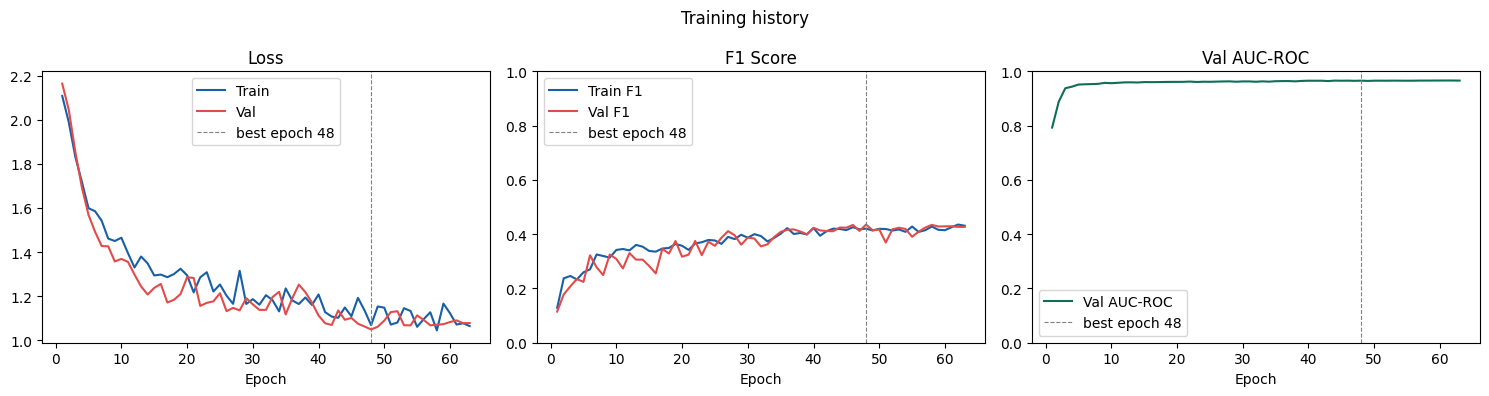


Final summary:
  Best epoch   : 48
  Best val F1  : 0.4353
  Best val AUC : 0.9662


In [48]:
# ── Cell 24: Training curves ──────────────────────────────────────────────────

epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training history", fontsize=12)

# ── loss ──────────────────────────────────────────────────────────────────────
axes[0].plot(x, history["train_loss"], label="Train", color="#185FA5")
axes[0].plot(x, history["val_loss"],   label="Val",   color="#E24B4A")
axes[0].axvline(best_epoch, color="gray", linestyle="--",
                linewidth=0.8, label=f"best epoch {best_epoch}")
axes[0].set_title("Loss");  axes[0].set_xlabel("Epoch")
axes[0].legend()

# ── F1 ────────────────────────────────────────────────────────────────────────
axes[1].plot(x, history["train_f1"], label="Train F1", color="#185FA5")
axes[1].plot(x, history["val_f1"],   label="Val F1",   color="#E24B4A")
axes[1].axvline(best_epoch, color="gray", linestyle="--",
                linewidth=0.8, label=f"best epoch {best_epoch}")
axes[1].set_title("F1 Score"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].legend()

# ── AUC ───────────────────────────────────────────────────────────────────────
axes[2].plot(x, history["val_auc"], color="#0F6E56", label="Val AUC-ROC")
axes[2].axvline(best_epoch, color="gray", linestyle="--",
                linewidth=0.8, label=f"best epoch {best_epoch}")
axes[2].set_title("Val AUC-ROC"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1); axes[2].legend()

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nFinal summary:")
print(f"  Best epoch   : {best_epoch}")
print(f"  Best val F1  : {best_val_f1:.4f}")
print(f"  Best val AUC : {max(history['val_auc']):.4f}")

In [49]:
# ══════════════════════════════════════════════════════════
# MOD-EVAL │ Test set evaluation (multi-class)
# ══════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating on test pool …\n")
te_loss, te_f1, te_auc = evaluate(model, test_graphs, CFG["batch_size"], DEVICE)

# Collect raw arrays for detailed metrics
all_preds, all_labels, all_probs = [], [], []
model.eval()
loader = PyGDataLoader(test_graphs, batch_size=CFG["batch_size"], shuffle=False)

with torch.no_grad():
    for batch in loader:
        batch  = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.edge_attr)
        mask   = batch.y >= 0
        if mask.sum() > 0:
            probs = torch.softmax(logits[mask], dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(batch.y[mask].cpu().numpy())

import numpy as np
all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print(f"Test Loss     : {te_loss:.4f}")
print(f"Test Macro-F1 : {te_f1:.4f}")
print(f"Test Macro-AUC: {te_auc:.4f}")
print()
print(classification_report(
    all_labels, all_preds,
    target_names=cat_encoder.classes_,
    digits=4
))

Evaluating on test pool …

Test Loss     : 1.1123
Test Macro-F1 : 0.4419
Test Macro-AUC: 0.9627

                precision    recall  f1-score   support

      Analysis     0.1765    0.2143    0.1935        28
      Backdoor     0.0875    0.2500    0.1296        28
           Dos     0.3282    0.6107    0.4269       244
      Exploits     0.7506    0.4523    0.5645       639
       Fuzzers     0.7250    0.7587    0.7415       344
       Generic     1.0000    0.9608    0.9800      2930
Reconnaissance     0.6590    0.6129    0.6351       186
     Shellcode     0.2195    0.3913    0.2812        23
         Worms     0.0123    1.0000    0.0244         1

      accuracy                         0.8255      4423
     macro avg     0.4398    0.5834    0.4419      4423
  weighted avg     0.8759    0.8255    0.8422      4423



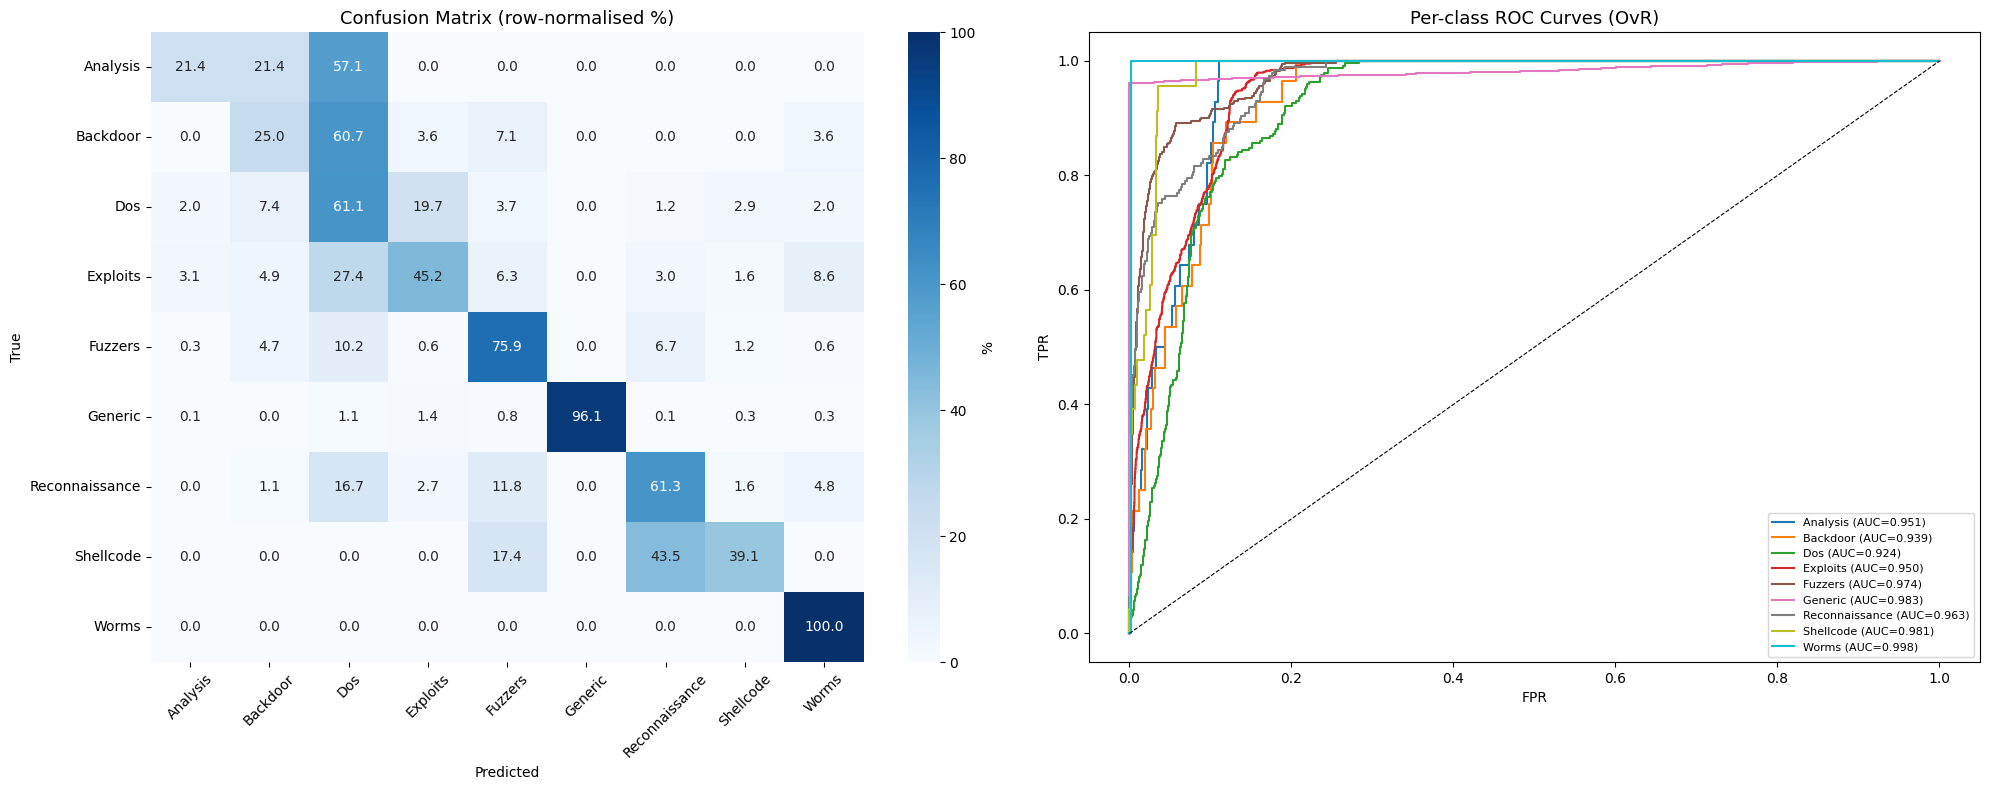

✅ Saved → /content/mc_eval_plots.png


In [50]:
# ══════════════════════════════════════════════════════════
# MOD-PLOTS │ 9×9 confusion matrix + per-class ROC
# ══════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
class_names = cat_encoder.classes_

# ── (A) Confusion matrix (row-normalised %) ───────────────
cm   = confusion_matrix(all_labels, all_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_n, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={"label": "%"})
axes[0].set_title("Confusion Matrix (row-normalised %)", fontsize=13)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=45)

# ── (B) Per-class ROC curves ──────────────────────────────
y_bin = label_binarize(all_labels, classes=list(range(NUM_ATTACK_CLS)))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_ATTACK_CLS))

for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_i = roc_auc_score(y_bin[:, i], all_probs[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=1.5,
                 label=f"{name} (AUC={auc_i:.3f})")

axes[1].plot([0,1],[0,1],"k--", lw=0.8)
axes[1].set_title("Per-class ROC Curves (OvR)", fontsize=13)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("/content/mc_eval_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → /content/mc_eval_plots.png")

  0%|          | 0/200 [00:00<?, ?it/s]


──────────────────────────────────────────────────────────────
  Category              Total   Recall      FNR  Status
──────────────────────────────────────────────────────────────
  Analysis                167    0.174    0.826  ❌
  Backdoor                162    0.253    0.747  ❌
  Dos                   1,097    0.068    0.932  ❌
  Exploits              2,893    0.048    0.952  ❌
  Fuzzers               1,599    0.041    0.959  ❌
  Generic              14,526    0.001    0.999  ❌
  Normal               71,932    0.016    0.984  ❌
  Reconnaissance          932    0.016    0.984  ❌
  Shellcode               101    0.000    1.000  ❌
  Worms                    13    0.000    1.000  ❌
──────────────────────────────────────────────────────────────


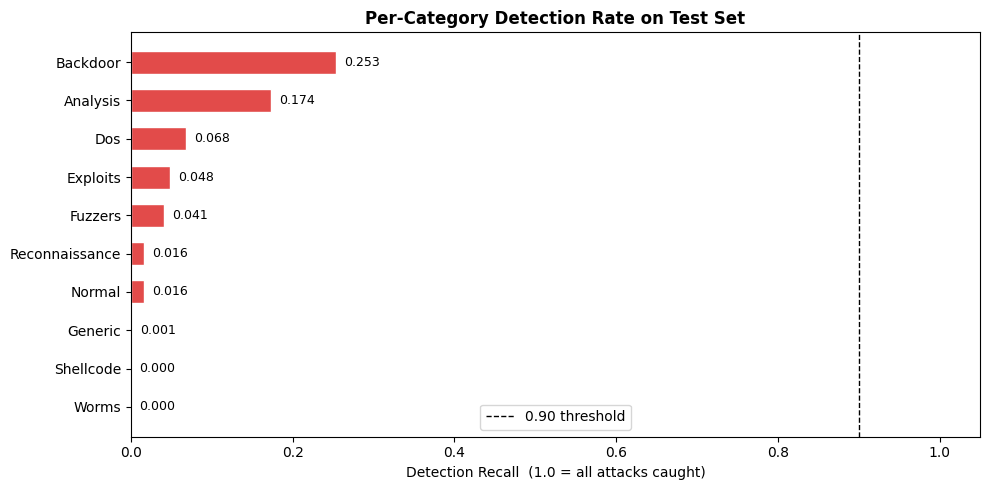


✅ Step 8 complete — evaluation done!


In [51]:
# ── Cell 27: Per-category breakdown ──────────────────────────────────────────
#
# Rebuilds test predictions node-by-node to attach attack_cat labels

print("Collecting per-category predictions …")
model.eval()

cat_preds, cat_labels, cat_names = [], [], []

with torch.no_grad():
    for w in tqdm(test_sampler.sample_n(200, stratified=True)):
        g = builder.build(w).to(DEVICE)
        logits = model(g.x, g.edge_index, g.edge_attr)
        preds  = logits.argmax(dim=-1).cpu().numpy()
        labels = g.y.cpu().numpy()
        cats   = w["attack_cat"].values       # attack category per flow

        cat_preds .extend(preds.tolist())
        cat_labels.extend(labels.tolist())
        cat_names .extend(cats.tolist())

cat_df = pd.DataFrame({
    "true"     : cat_labels,
    "pred"     : cat_preds,
    "category" : cat_names,
})

# ── Per-category metrics ───────────────────────────────────────────────────────
print(f"\n{'─'*62}")
print(f"  {'Category':<20} {'Total':>6}  {'Recall':>7}  {'FNR':>7}  {'Status'}")
print(f"{'─'*62}")

results = []
for cat in sorted(cat_df["category"].unique()):
    sub = cat_df[cat_df["category"] == cat]
    n   = len(sub)

    if cat == "Normal":
        # for normal: measure specificity (correct normal predictions)
        correct = (sub["true"] == sub["pred"]).sum()
        recall  = correct / n
        fnr     = 1 - recall
        status  = "✅" if recall > 0.95 else ("⚠️ " if recall > 0.85 else "❌")
        label   = "Specificity"
    else:
        # for attacks: measure recall (attack detection rate)
        detected = ((sub["true"] == 1) & (sub["pred"] == 1)).sum()
        total_a  = (sub["true"] == 1).sum()
        recall   = detected / total_a if total_a > 0 else 0
        fnr      = 1 - recall
        status   = "✅" if recall > 0.90 else ("⚠️ " if recall > 0.70 else "❌")
        label    = "Recall"

    results.append((cat, n, recall, fnr, status))
    print(f"  {cat:<20} {n:>6,}  {recall:>7.3f}  {fnr:>7.3f}  {status}")

print(f"{'─'*62}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results,
                           columns=["category","n","recall","fnr","status"])
results_df = results_df.sort_values("recall", ascending=True)

colors = ["#E24B4A" if s == "❌" else
          "#BA7517" if s == "⚠️ " else
          "#0F6E56"
          for s in results_df["status"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(results_df["category"], results_df["recall"],
               color=colors, edgecolor="white", height=0.6)
ax.axvline(0.90, color="black", linestyle="--",
           linewidth=1, label="0.90 threshold")
ax.set_xlabel("Detection Recall  (1.0 = all attacks caught)")
ax.set_title("Per-Category Detection Rate on Test Set", fontweight="bold")
ax.set_xlim(0, 1.05)
ax.legend()

for bar, val in zip(bars, results_df["recall"]):
    ax.text(min(val + 0.01, 1.01), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/category_detection.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\n✅ Step 8 complete — evaluation done!")

Per-category error breakdown

Category               Total   Correct   Errors   Error%  Error Type
────────────────────────────────────────────────────────────────────────
  Normal              71,932     1,126    3,534     4.9%  False Positive  ✅
  Exploits             2,893       139       69     2.4%  False Negative  ✅
  Analysis               167        29       35    21.0%  False Negative  ❌
  Dos                  1,097        75       17     1.5%  False Negative  ✅
  Generic             14,526        10       12     0.1%  False Negative  ✅
  Fuzzers              1,599        65        1     0.1%  False Negative  ✅
  Reconnaissance         932        15        1     0.1%  False Negative  ✅
  Backdoor               162        41        0     0.0%  False Negative  ✅
  Shellcode              101         0        0     0.0%  False Negative  ✅
  Worms                   13         0        0     0.0%  False Negative  ✅
────────────────────────────────────────────────────────────────────

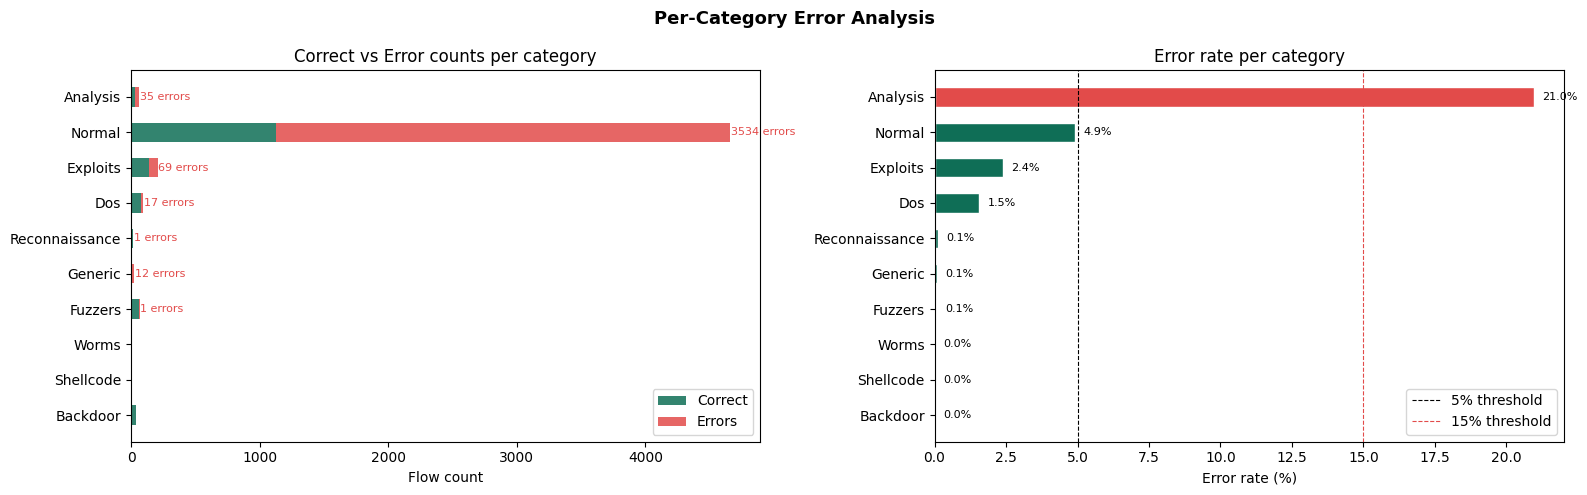


── Error summary ───────────────────────────────────────
  False Positives (normal → attack) : 3,534  ← false alarms
  False Negatives (attack → normal) : 135  ← missed attacks  ⚠️  more dangerous for IDS
  Worst category  : Normal  (4.9% error rate)
  Best  category  : Worms  (0.0% error rate)


In [52]:
# ── Cell 27b: Per-category error counts ──────────────────────────────────────

print("Per-category error breakdown\n")

error_rows = []

for cat in sorted(cat_df["category"].unique()):
    sub = cat_df[cat_df["category"] == cat]
    n   = len(sub)

    if cat == "Normal":
        tp = ((sub["true"] == 0) & (sub["pred"] == 0)).sum()  # correct normal
        fp = ((sub["true"] == 0) & (sub["pred"] == 1)).sum()  # normal → attack
        fn = 0
        tn = 0
        error_rows.append({
            "Category"        : cat,
            "Total flows"     : n,
            "Correct"         : tp,
            "False Alarms"    : fp,   # predicted attack but was normal
            "Missed Attacks"  : 0,
            "Error count"     : fp,
            "Error rate"      : fp / n if n > 0 else 0,
            "Error type"      : "False Positive",
        })
    else:
        total_attacks = (sub["true"] == 1).sum()
        detected      = ((sub["true"] == 1) & (sub["pred"] == 1)).sum()
        missed        = ((sub["true"] == 1) & (sub["pred"] == 0)).sum()  # attack → normal
        error_rows.append({
            "Category"        : cat,
            "Total flows"     : n,
            "Correct"         : detected,
            "False Alarms"    : 0,
            "Missed Attacks"  : missed,
            "Error count"     : missed,
            "Error rate"      : missed / total_attacks if total_attacks > 0 else 0,
            "Error type"      : "False Negative",
        })

err_df = pd.DataFrame(error_rows).sort_values("Error count", ascending=False)

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Category':<20} {'Total':>7}  {'Correct':>8}  "
      f"{'Errors':>7}  {'Error%':>7}  {'Error Type'}")
print("─" * 72)

for _, row in err_df.iterrows():
    flag = ("❌" if row["Error rate"] > 0.15 else
            "⚠️ " if row["Error rate"] > 0.05 else "✅")
    print(f"  {row['Category']:<18} {int(row['Total flows']):>7,}  "
          f"{int(row['Correct']):>8,}  "
          f"{int(row['Error count']):>7,}  "
          f"{100*row['Error rate']:>6.1f}%  "
          f"{row['Error type']}  {flag}")

print("─" * 72)
total_errors = err_df["Error count"].sum()
total_flows  = err_df["Total flows"].sum()
print(f"  {'TOTAL':<18} {int(total_flows):>7,}  "
      f"{int(total_flows - total_errors):>8,}  "
      f"{int(total_errors):>7,}  "
      f"{100*total_errors/total_flows:>6.1f}%")

# ── Stacked bar: correct vs errors per category ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Per-Category Error Analysis", fontsize=13, fontweight="bold")

plot_df = err_df.sort_values("Error rate", ascending=True)
cats    = plot_df["Category"]
x       = np.arange(len(cats))

# ── (A) Stacked bar: correct vs error counts ──────────────────────────────────
axes[0].barh(cats, plot_df["Correct"],
             color="#0F6E56", alpha=0.85,
             label="Correct", height=0.55)
axes[0].barh(cats, plot_df["Error count"],
             left=plot_df["Correct"],
             color="#E24B4A", alpha=0.85,
             label="Errors", height=0.55)

# annotate error counts on bars
for i, (_, row) in enumerate(plot_df.iterrows()):
    if row["Error count"] > 0:
        axes[0].text(
            row["Correct"] + row["Error count"] + 5,
            i, f'{int(row["Error count"])} errors',
            va="center", fontsize=8, color="#E24B4A"
        )

axes[0].set_xlabel("Flow count")
axes[0].set_title("Correct vs Error counts per category")
axes[0].legend(loc="lower right")

# ── (B) Error rate per category ───────────────────────────────────────────────
bar_colors = ["#E24B4A" if r > 0.15 else
              "#BA7517" if r > 0.05 else
              "#0F6E56"
              for r in plot_df["Error rate"]]

axes[1].barh(cats, plot_df["Error rate"] * 100,
             color=bar_colors, edgecolor="white", height=0.55)
axes[1].axvline(5,  color="black",  linestyle="--",
                linewidth=0.8, label="5% threshold")
axes[1].axvline(15, color="#E24B4A", linestyle="--",
                linewidth=0.8, label="15% threshold")

for i, (_, row) in enumerate(plot_df.iterrows()):
    axes[1].text(
        row["Error rate"] * 100 + 0.3, i,
        f'{100*row["Error rate"]:.1f}%',
        va="center", fontsize=8
    )

axes[1].set_xlabel("Error rate (%)")
axes[1].set_title("Error rate per category")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("/content/error_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n── Error summary ───────────────────────────────────────")
fp_total = err_df[err_df["Error type"] == "False Positive"]["Error count"].sum()
fn_total = err_df[err_df["Error type"] == "False Negative"]["Error count"].sum()
print(f"  False Positives (normal → attack) : {int(fp_total):,}  "
      f"← false alarms")
print(f"  False Negatives (attack → normal) : {int(fn_total):,}  "
      f"← missed attacks  ⚠️  more dangerous for IDS")
print(f"  Worst category  : "
      f"{err_df.iloc[0]['Category']}  "
      f"({100*err_df.iloc[0]['Error rate']:.1f}% error rate)")
print(f"  Best  category  : "
      f"{err_df.iloc[-1]['Category']}  "
      f"({100*err_df.iloc[-1]['Error rate']:.1f}% error rate)")

In [54]:
import numpy as np
# ══════════════════════════════════════════════════════════
# MOD-INFER │ Full dataset inference (multi-class)
# ══════════════════════════════════════════════════════════
INFER_WINDOW = 500

def full_split_inference(split_df, split_name):
    """
    Slides a fixed window across the entire split.
    Returns arrays for ATTACK NODES ONLY (Normal masked out).
    """
    all_labels, all_preds, all_probs, all_cats = [], [], [], []
    n_windows = len(split_df) // INFER_WINDOW
    model.eval()

    with torch.no_grad():
        for i in tqdm(range(n_windows), desc=split_name):
            window = split_df.iloc[i*INFER_WINDOW:(i+1)*INFER_WINDOW]
            # Reset the index of the window to be 0-based
            window = window.reset_index(drop=True)
            g      = mc_builder.build(window).to(DEVICE)
            logits = model(g.x, g.edge_index, g.edge_attr)

            mask = g.y >= 0           # attack nodes only
            if mask.sum() == 0:
                continue

            probs = torch.softmax(logits[mask], dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(g.y[mask].cpu().numpy())
            all_cats.extend(
                window[window["label"] == 1]["attack_cat"].values[:mask.sum().item()]
            )

    return (np.array(all_labels), np.array(all_preds),
            np.array(all_probs),  np.array(all_cats))

train_labels, train_preds, train_probs, train_cats = full_split_inference(df_train, "train")
val_labels,   val_preds,   val_probs,   val_cats   = full_split_inference(df_val,   "val")
test_labels,  test_preds,  test_probs,  test_cats  = full_split_inference(df_test,  "test")

print(f"\nFlows evaluated (attack only):")
print(f"  train : {len(train_labels):,}")
print(f"  val   : {len(val_labels):,}")
print(f"  test  : {len(test_labels):,}")

train:   0%|          | 0/3556 [00:00<?, ?it/s]

val:   0%|          | 0/762 [00:00<?, ?it/s]

test:   0%|          | 0/762 [00:00<?, ?it/s]


Flows evaluated (attack only):
  train : 224,892
  val   : 48,190
  test  : 48,188


In [55]:
# ══════════════════════════════════════════════════════════
# MOD-REPORT │ Full metrics report (multi-class)
# ══════════════════════════════════════════════════════════
def compute_mc_metrics(labels, preds, probs, split_name):
    macro_f1  = f1_score(labels, preds, average="macro",  zero_division=0)
    micro_f1  = f1_score(labels, preds, average="micro",  zero_division=0)
    try:
        macro_auc = roc_auc_score(
            label_binarize(labels, classes=list(range(NUM_ATTACK_CLS))),
            probs, average="macro"
        )
    except ValueError:
        macro_auc = float("nan")

    print(f"\n{'═'*52}")
    print(f"  {split_name.upper()} SPLIT")
    print(f"{'─'*52}")
    print(f"  Macro  F1  : {macro_f1:.4f}")
    print(f"  Micro  F1  : {micro_f1:.4f}")
    print(f"  Macro AUC  : {macro_auc:.4f}")
    print(f"{'─'*52}")
    print(classification_report(
        labels, preds,
        target_names=cat_encoder.classes_, digits=4
    ))
    return {"macro_f1": macro_f1, "micro_f1": micro_f1, "macro_auc": macro_auc}

train_metrics = compute_mc_metrics(train_labels, train_preds, train_probs, "train")
val_metrics   = compute_mc_metrics(val_labels,   val_preds,   val_probs,   "val")
test_metrics  = compute_mc_metrics(test_labels,  test_preds,  test_probs,  "test")

# Save to CSV
import pandas as pd
metrics_df = pd.DataFrame([
    {"split":"train", **train_metrics},
    {"split":"val",   **val_metrics},
    {"split":"test",  **test_metrics},
])
metrics_df.to_csv(f"{SAVE_DIR}/final_metrics_mc.csv", index=False)
print(f"\n✅ Saved → {SAVE_DIR}/final_metrics_mc.csv")


════════════════════════════════════════════════════
  TRAIN SPLIT
────────────────────────────────────────────────────
  Macro  F1  : 0.4731
  Micro  F1  : 0.8429
  Macro AUC  : 0.9668
────────────────────────────────────────────────────
                precision    recall  f1-score   support

      Analysis     0.2629    0.2097    0.2333      1917
      Backdoor     0.1112    0.2412    0.1522      1617
           Dos     0.3345    0.7119    0.4551     11436
      Exploits     0.8228    0.4285    0.5635     31203
       Fuzzers     0.7605    0.7896    0.7748     16923
       Generic     0.9998    0.9734    0.9864    150894
Reconnaissance     0.7296    0.6508    0.6880      9717
     Shellcode     0.2645    0.5573    0.3587      1064
         Worms     0.0235    0.7521    0.0456       121

      accuracy                         0.8429    224892
     macro avg     0.4788    0.5905    0.4731    224892
  weighted avg     0.8950    0.8429    0.8560    224892


════════════════════════════

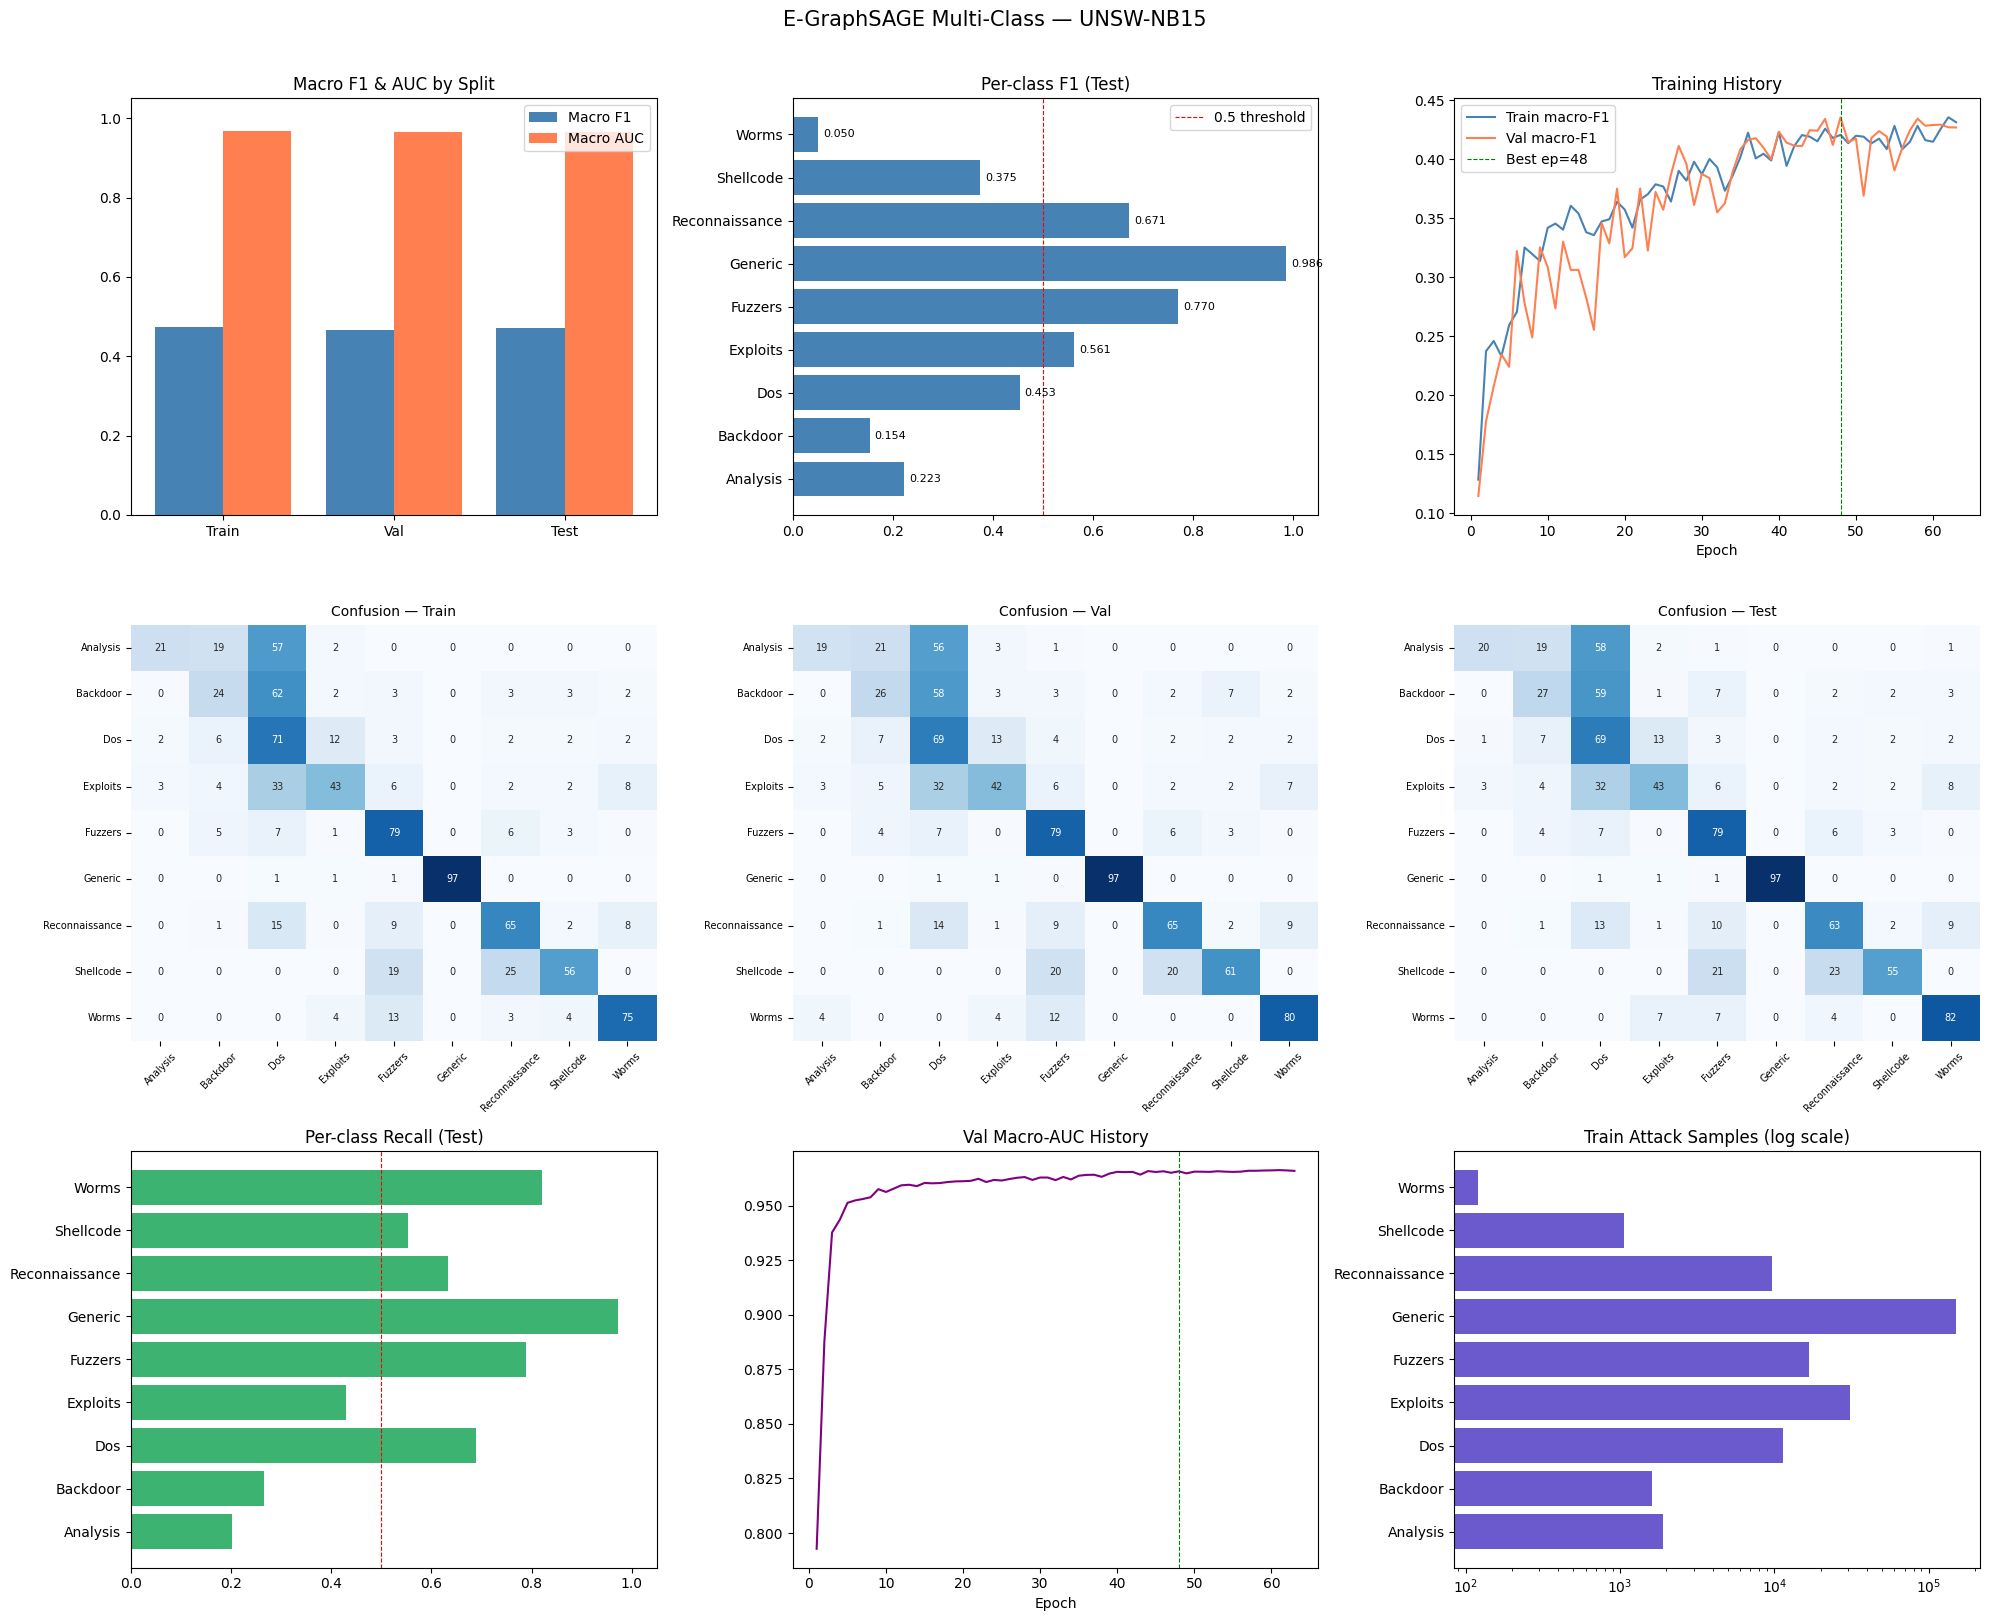

✅ Saved → /content/final_report_mc.png


In [56]:
# ══════════════════════════════════════════════════════════
# MOD-DASH │ Final visual dashboard (multi-class)
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 16))
fig.suptitle("E-GraphSAGE Multi-Class — UNSW-NB15", fontsize=15, y=1.01)
class_names = cat_encoder.classes_

# ── [0,0] Macro F1 / AUC per split ───────────────────────
ax = fig.add_subplot(3, 3, 1)
x  = np.arange(3)
splits = ["Train", "Val", "Test"]
f1s  = [train_metrics["macro_f1"], val_metrics["macro_f1"], test_metrics["macro_f1"]]
aucs = [train_metrics["macro_auc"],val_metrics["macro_auc"],test_metrics["macro_auc"]]
ax.bar(x - 0.2, f1s,  0.4, label="Macro F1",  color="steelblue")
ax.bar(x + 0.2, aucs, 0.4, label="Macro AUC", color="coral")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylim(0, 1.05); ax.legend(); ax.set_title("Macro F1 & AUC by Split")

# ── [0,1] Per-class F1 (test) ─────────────────────────────
ax = fig.add_subplot(3, 3, 2)
from sklearn.metrics import f1_score as f1_per
per_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
bars = ax.barh(class_names, per_f1, color="steelblue")
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color="red", ls="--", lw=0.8, label="0.5 threshold")
ax.set_title("Per-class F1 (Test)"); ax.legend()
for bar, v in zip(bars, per_f1):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=8)

# ── [0,2] Training curves ────────────────────────────────
ax = fig.add_subplot(3, 3, 3)
ep = range(1, len(history["val_f1"]) + 1)
ax.plot(ep, history["train_f1"], label="Train macro-F1", color="steelblue")
ax.plot(ep, history["val_f1"],   label="Val macro-F1",   color="coral")
ax.axvline(best_epoch, color="green", ls="--", lw=0.8, label=f"Best ep={best_epoch}")
ax.set_title("Training History"); ax.legend(); ax.set_xlabel("Epoch")

# ── [1,0] Confusion matrix train ─────────────────────────
for idx, (lbl, prd, title) in enumerate([
    (train_labels, train_preds, "Confusion — Train"),
    (val_labels,   val_preds,   "Confusion — Val"),
    (test_labels,  test_preds,  "Confusion — Test"),
]):
    ax  = fig.add_subplot(3, 3, 4 + idx)
    cm  = confusion_matrix(lbl, prd)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cmn, annot=True, fmt=".0f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={"size": 7})
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

# ── [2,0] Per-class recall (test) ─────────────────────────
ax = fig.add_subplot(3, 3, 7)
from sklearn.metrics import recall_score
per_rec = recall_score(test_labels, test_preds, average=None, zero_division=0)
ax.barh(class_names, per_rec, color="mediumseagreen")
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color="red", ls="--", lw=0.8)
ax.set_title("Per-class Recall (Test)")

# ── [2,1] Val AUC history ────────────────────────────────
ax = fig.add_subplot(3, 3, 8)
ax.plot(ep, history["val_auc"], color="purple")
ax.axvline(best_epoch, color="green", ls="--", lw=0.8)
ax.set_title("Val Macro-AUC History"); ax.set_xlabel("Epoch")

# ── [2,2] Class sample counts ────────────────────────────
ax = fig.add_subplot(3, 3, 9)
counts = [(_attack_counts.get(i, 0)) for i in range(NUM_ATTACK_CLS)]
ax.barh(class_names, counts, color="slateblue")
ax.set_xscale("log")
ax.set_title("Train Attack Samples (log scale)")

plt.tight_layout()
plt.savefig("/content/final_report_mc.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → /content/final_report_mc.png")

In [57]:
import os
import zipfile
from google.colab import files

# Files and folders to include
items = [
   "/content/graphsage_mc_unswnb15",
   "/content/category_detection.png",
   "/content/error_analysis.png",
   "/content/final_report_mc.png",
   "/content/graph_stats.png",
   "/content/mc_eval_plots.png",
   "/content/training_curves.png"
]

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for item in items:
        if os.path.isdir(item):
            # Add all files in the folder
            for root, dirs, filenames in os.walk(item):
                for filename in filenames:
                    file_path = os.path.join(root, filename)
                    arcname = os.path.relpath(file_path, "/content")
                    zipf.write(file_path, arcname)
        elif os.path.isfile(item):
            # Add individual file
            arcname = os.path.relpath(item, "/content")
            zipf.write(item, arcname)
        else:
            print(f"Skipping (not found): {item}")

# Download the ZIP
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>